### Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tempfile
import os

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV, cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.impute import SimpleImputer
from tqdm import tqdm
import pymc as pm
import arviz as az
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import scikit_posthocs as sp
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import baycomp

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


### Lectura y Preparación de los Modelos

In [3]:
ruta = r'C:\Users\Manuel Montufar\Documents\ProyectosparaPortafolio\Spaceship Titanic\Data\Base_Limpia.parquet'
df = pd.read_parquet(f'{ruta}')

In [4]:
df

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Cabin Type
0,0001_01,Europa,0,TRAPPIST-1e,39,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0
1,0002_01,Earth,0,TRAPPIST-1e,24,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,1
2,0003_01,Europa,0,TRAPPIST-1e,58,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,1
3,0003_02,Europa,0,TRAPPIST-1e,33,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,1
4,0004_01,Earth,0,TRAPPIST-1e,16,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,0,55 Cancri e,41,1,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,0
8689,9278_01,Earth,1,PSO J318.5-22,18,0,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,1
8690,9279_01,Earth,0,TRAPPIST-1e,26,0,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,1
8691,9280_01,Europa,0,55 Cancri e,32,0,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,1


In [5]:
# Label Encoders
# Ajustar y transformar la columna
# Inicializar el LabelEncoder
le = LabelEncoder()
df['HomePlanet'] = le.fit_transform(df['HomePlanet'])
df['Destination'] = le.fit_transform(df['Destination'])

In [6]:
# Separar las características (X) y la variable objetivo (y)
X = df.drop(columns=['Transported', 'PassengerId', 'Name'])
y = df['Transported']

In [7]:
print(df)

     PassengerId  HomePlanet  CryoSleep  Destination  Age  VIP  RoomService  \
0        0001_01           1          0            2   39    0          0.0   
1        0002_01           0          0            2   24    0        109.0   
2        0003_01           1          0            2   58    1         43.0   
3        0003_02           1          0            2   33    0          0.0   
4        0004_01           0          0            2   16    0        303.0   
...          ...         ...        ...          ...  ...  ...          ...   
8688     9276_01           1          0            0   41    1          0.0   
8689     9278_01           0          1            1   18    0          0.0   
8690     9279_01           0          0            2   26    0          0.0   
8691     9280_01           1          0            0   32    0          0.0   
8692     9280_02           1          0            2   44    0        126.0   

      FoodCourt  ShoppingMall     Spa  VRDeck      

In [8]:
# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### El Mejor Modelo?

In [9]:
# Definir los clasificadores individuales
gb = GradientBoostingClassifier(n_estimators=800, learning_rate=0.01, max_depth=4, subsample=0.75, random_state=42)
xgb = XGBClassifier(n_estimators=1500, learning_rate=0.01, max_depth=4, subsample=0.75, random_state=1)
svc = SVC(probability=True, kernel='rbf', C=1, gamma=0.1, random_state=42)
voting_clf_svc = VotingClassifier(estimators=[('gb', gb), ('svc', svc), ('xgb', xgb)], voting='soft')
ada = AdaBoostClassifier(n_estimators=600, learning_rate=0.01, algorithm='SAMME', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
voting_good = VotingClassifier(estimators=[('xgb', xgb), ('ada', ada), ('knn', knn)], voting='soft')
cat_boost = CatBoostClassifier(depth=4, iterations=1500, l2_leaf_reg=3, learning_rate=0.1, random_state=42)
voting_cat = VotingClassifier(estimators=[('cat', cat_boost), ('ada', ada), ('knn', knn)], voting='soft')


# Diccionario final con todos los clasificadores
classifiers = {
    'XGBoost': xgb,
    'CatBoost': cat_boost,
    'VotingClassifier con SVC': voting_clf_svc,
    'VotingClassifier Ajustado': voting_good,
    'Voting Classifier con CatBoost': voting_cat
}

# Definir las métricas para la validación cruzada
scoring = {
    'Accuracy': 'accuracy',
    'Precision': 'precision_weighted',
    'Recall': 'recall_weighted',
    'F1': 'f1_weighted',
    'ROC AUC': 'roc_auc'
}

# Evaluar los clasificadores utilizando 5-fold cross-validation y guardar los resultados por métrica
results = {}
for name, model in tqdm(classifiers.items(), desc="Evaluando Modelos"):
    results[name] = {}
    for metric_name, metric in tqdm(scoring.items(), desc=f"Evaluando métricas para {name}", leave=False):
        scores = cross_val_score(model, X, y, cv=5, scoring=metric)
        results[name][metric_name] = scores  # Guardar los 5 resultados individuales

# Convertir los resultados a un DataFrame para cada métrica
accuracy_df = pd.DataFrame({model: results[model]['Accuracy'] for model in classifiers.keys()})
precision_df = pd.DataFrame({model: results[model]['Precision'] for model in classifiers.keys()})
recall_df = pd.DataFrame({model: results[model]['Recall'] for model in classifiers.keys()})
f1_df = pd.DataFrame({model: results[model]['F1'] for model in classifiers.keys()})
roc_auc_df = pd.DataFrame({model: results[model]['ROC AUC'] for model in classifiers.keys()})

# Mostrar los DataFrames con los resultados
print("Accuracy:\n", accuracy_df)
print("Precision:\n", precision_df)
print("Recall:\n", recall_df)
print("F1 Score:\n", f1_df)
print("ROC AUC:\n", roc_auc_df)


Evaluando Modelos:  20%|██        | 1/5 [00:31<02:04, 31.04s/it]

0:	learn: 0.6590237	total: 166ms	remaining: 4m 9s
1:	learn: 0.6276192	total: 173ms	remaining: 2m 9s
2:	learn: 0.6035283	total: 178ms	remaining: 1m 28s
3:	learn: 0.5803045	total: 185ms	remaining: 1m 9s
4:	learn: 0.5631326	total: 190ms	remaining: 56.8s
5:	learn: 0.5501269	total: 196ms	remaining: 48.9s
6:	learn: 0.5363715	total: 203ms	remaining: 43.3s
7:	learn: 0.5271744	total: 210ms	remaining: 39.1s
8:	learn: 0.5162913	total: 217ms	remaining: 36s
9:	learn: 0.5095446	total: 222ms	remaining: 33s
10:	learn: 0.5027091	total: 225ms	remaining: 30.4s
11:	learn: 0.4986046	total: 230ms	remaining: 28.5s
12:	learn: 0.4907728	total: 235ms	remaining: 26.8s
13:	learn: 0.4856456	total: 239ms	remaining: 25.3s
14:	learn: 0.4818813	total: 243ms	remaining: 24.1s
15:	learn: 0.4780349	total: 247ms	remaining: 22.9s
16:	learn: 0.4735969	total: 251ms	remaining: 21.9s
17:	learn: 0.4702960	total: 255ms	remaining: 21s
18:	learn: 0.4671115	total: 259ms	remaining: 20.2s
19:	learn: 0.4642239	total: 263ms	remaining: 1

1434:	learn: 0.2652173	total: 4.47s	remaining: 202ms
1435:	learn: 0.2651469	total: 4.47s	remaining: 199ms
1436:	learn: 0.2651014	total: 4.47s	remaining: 196ms
1437:	learn: 0.2650804	total: 4.48s	remaining: 193ms
1438:	learn: 0.2650598	total: 4.48s	remaining: 190ms
1439:	learn: 0.2649944	total: 4.48s	remaining: 187ms
1440:	learn: 0.2649528	total: 4.49s	remaining: 184ms
1441:	learn: 0.2649222	total: 4.49s	remaining: 181ms
1442:	learn: 0.2648980	total: 4.49s	remaining: 177ms
1443:	learn: 0.2648263	total: 4.49s	remaining: 174ms
1444:	learn: 0.2648180	total: 4.5s	remaining: 171ms
1445:	learn: 0.2647678	total: 4.5s	remaining: 168ms
1446:	learn: 0.2646899	total: 4.5s	remaining: 165ms
1447:	learn: 0.2646082	total: 4.5s	remaining: 162ms
1448:	learn: 0.2645681	total: 4.51s	remaining: 159ms
1449:	learn: 0.2645269	total: 4.51s	remaining: 156ms
1450:	learn: 0.2644349	total: 4.51s	remaining: 152ms
1451:	learn: 0.2643896	total: 4.52s	remaining: 149ms
1452:	learn: 0.2643239	total: 4.52s	remaining: 146

Evaluando métricas para CatBoost:  20%|██        | 1/5 [00:23<01:32, 23.21s/it]

0:	learn: 0.6590237	total: 2.62ms	remaining: 3.92s
1:	learn: 0.6276192	total: 5.1ms	remaining: 3.82s
2:	learn: 0.6035283	total: 7.63ms	remaining: 3.81s
3:	learn: 0.5803045	total: 11.1ms	remaining: 4.14s
4:	learn: 0.5631326	total: 14.3ms	remaining: 4.28s
5:	learn: 0.5501269	total: 17.8ms	remaining: 4.42s
6:	learn: 0.5363715	total: 20.7ms	remaining: 4.41s
7:	learn: 0.5271744	total: 23.3ms	remaining: 4.34s
8:	learn: 0.5162913	total: 26.8ms	remaining: 4.44s
9:	learn: 0.5095446	total: 30.1ms	remaining: 4.49s
10:	learn: 0.5027091	total: 33.7ms	remaining: 4.56s
11:	learn: 0.4986046	total: 37.9ms	remaining: 4.7s
12:	learn: 0.4907728	total: 42.1ms	remaining: 4.81s
13:	learn: 0.4856456	total: 46.2ms	remaining: 4.91s
14:	learn: 0.4818813	total: 49.6ms	remaining: 4.91s
15:	learn: 0.4780349	total: 52.9ms	remaining: 4.9s
16:	learn: 0.4735969	total: 56ms	remaining: 4.89s
17:	learn: 0.4702960	total: 59.1ms	remaining: 4.87s
18:	learn: 0.4671115	total: 61.8ms	remaining: 4.82s
19:	learn: 0.4642239	total:

...

0:	learn: 0.6590237	total: 3.34ms	remaining: 5.01s
1:	learn: 0.6276192	total: 6.42ms	remaining: 4.81s
2:	learn: 0.6035283	total: 9.44ms	remaining: 4.71s
3:	learn: 0.5803045	total: 12.9ms	remaining: 4.84s
4:	learn: 0.5631326	total: 16ms	remaining: 4.78s
5:	learn: 0.5501269	total: 18.4ms	remaining: 4.59s
6:	learn: 0.5363715	total: 21.6ms	remaining: 4.6s
7:	learn: 0.5271744	total: 23.8ms	remaining: 4.44s
8:	learn: 0.5162913	total: 27.1ms	remaining: 4.48s
9:	learn: 0.5095446	total: 29.8ms	remaining: 4.44s
10:	learn: 0.5027091	total: 32.7ms	remaining: 4.42s
11:	learn: 0.4986046	total: 35.3ms	remaining: 4.38s
12:	learn: 0.4907728	total: 38.4ms	remaining: 4.39s
13:	learn: 0.4856456	total: 41.2ms	remaining: 4.37s
14:	learn: 0.4818813	total: 44.5ms	remaining: 4.41s
15:	learn: 0.4780349	total: 47.3ms	remaining: 4.39s
16:	learn: 0.4735969	total: 50.2ms	remaining: 4.38s
17:	learn: 0.4702960	total: 52.9ms	remaining: 4.35s
18:	learn: 0.4671115	total: 55.6ms	remaining: 4.33s
19:	learn: 0.4642239	tota

0:	learn: 0.6590237	total: 3.86ms	remaining: 5.79s
1:	learn: 0.6276192	total: 8.53ms	remaining: 6.39s
2:	learn: 0.6035283	total: 12.3ms	remaining: 6.16s
3:	learn: 0.5803045	total: 16.1ms	remaining: 6.02s
4:	learn: 0.5631326	total: 19.3ms	remaining: 5.76s
5:	learn: 0.5501269	total: 22.2ms	remaining: 5.53s
6:	learn: 0.5363715	total: 25ms	remaining: 5.33s
7:	learn: 0.5271744	total: 27.9ms	remaining: 5.21s
8:	learn: 0.5162913	total: 30.1ms	remaining: 4.99s
9:	learn: 0.5095446	total: 33.6ms	remaining: 5.01s
10:	learn: 0.5027091	total: 37.1ms	remaining: 5.02s
11:	learn: 0.4986046	total: 39.7ms	remaining: 4.92s
12:	learn: 0.4907728	total: 42ms	remaining: 4.81s
13:	learn: 0.4856456	total: 44.5ms	remaining: 4.72s
14:	learn: 0.4818813	total: 47.1ms	remaining: 4.67s
15:	learn: 0.4780349	total: 49.3ms	remaining: 4.58s
16:	learn: 0.4735969	total: 51.5ms	remaining: 4.49s
17:	learn: 0.4702960	total: 54.1ms	remaining: 4.45s
18:	learn: 0.4671115	total: 56.5ms	remaining: 4.4s
19:	learn: 0.4642239	total:

0:	learn: 0.6590237	total: 7.51ms	remaining: 11.3s
1:	learn: 0.6276192	total: 15.2ms	remaining: 11.4s
2:	learn: 0.6035283	total: 22.5ms	remaining: 11.2s
3:	learn: 0.5803045	total: 29.2ms	remaining: 10.9s
4:	learn: 0.5631326	total: 35.9ms	remaining: 10.7s
5:	learn: 0.5501269	total: 43.8ms	remaining: 10.9s
6:	learn: 0.5363715	total: 50.3ms	remaining: 10.7s
7:	learn: 0.5271744	total: 56.7ms	remaining: 10.6s
8:	learn: 0.5162913	total: 64.1ms	remaining: 10.6s
9:	learn: 0.5095446	total: 71.4ms	remaining: 10.6s
10:	learn: 0.5027091	total: 77.5ms	remaining: 10.5s
11:	learn: 0.4986046	total: 85.6ms	remaining: 10.6s
12:	learn: 0.4907728	total: 92.4ms	remaining: 10.6s
13:	learn: 0.4856456	total: 99.7ms	remaining: 10.6s
14:	learn: 0.4818813	total: 107ms	remaining: 10.6s
15:	learn: 0.4780349	total: 114ms	remaining: 10.5s
16:	learn: 0.4735969	total: 121ms	remaining: 10.6s
17:	learn: 0.4702960	total: 128ms	remaining: 10.5s
18:	learn: 0.4671115	total: 136ms	remaining: 10.6s
19:	learn: 0.4642239	total:

Evaluando Modelos: 100%|██████████| 5/5 [23:26<00:00, 281.22s/it]

Accuracy:
     XGBoost  CatBoost  VotingClassifier con SVC  VotingClassifier Ajustado  \
0  0.782059  0.779183                  0.779758                   0.784934   
1  0.787234  0.783209                  0.785509                   0.780909   
2  0.798735  0.794710                  0.787234                   0.794710   
3  0.810127  0.806674                  0.802647                   0.809551   
4  0.797468  0.787687                  0.802071                   0.800921   

   Voting Classifier con CatBoost  
0                        0.784359  
1                        0.777458  
2                        0.793560  
3                        0.800345  
4                        0.803222  
Precision:
     XGBoost  CatBoost  VotingClassifier con SVC  VotingClassifier Ajustado  \
0  0.784499  0.780584                  0.780557                   0.787465   
1  0.789196  0.784410                  0.786401                   0.783718   
2  0.798813  0.794997                  0.789959           

### Metricas

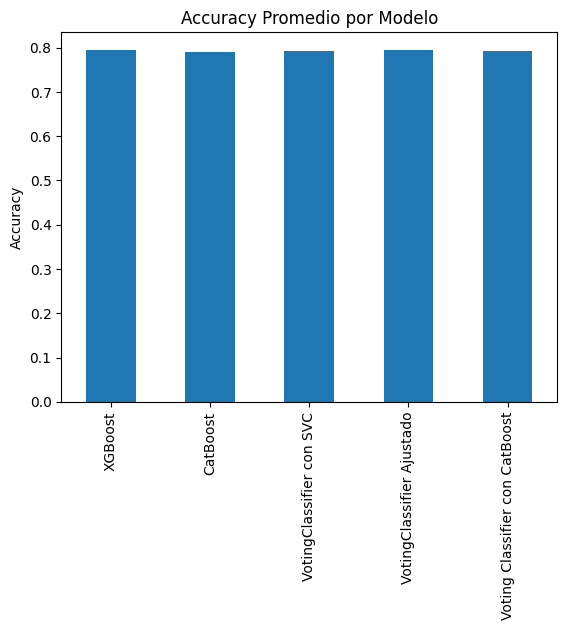

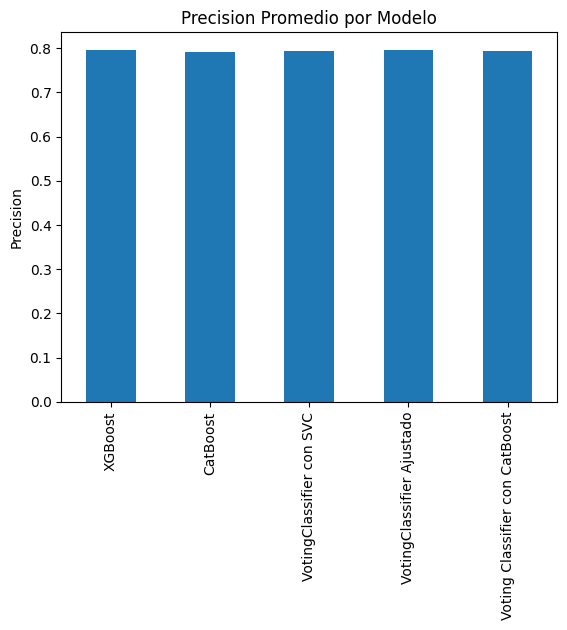

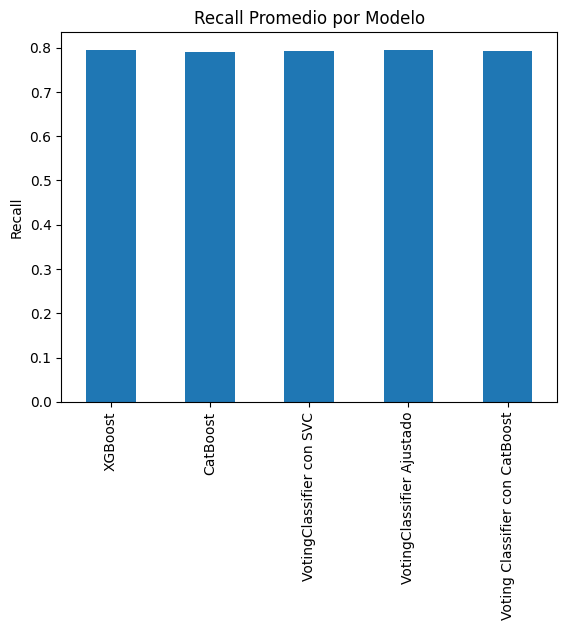

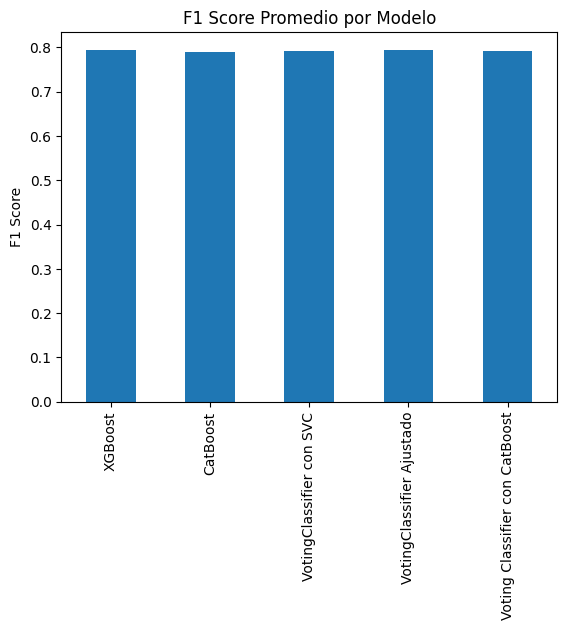

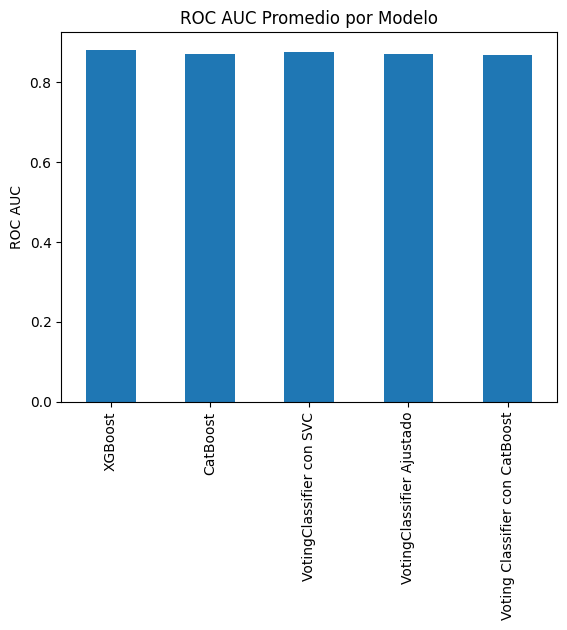

In [10]:
# Calcular los promedios de cada métrica
accuracy_mean = accuracy_df.mean()
precision_mean = precision_df.mean()
recall_mean = recall_df.mean()
f1_mean = f1_df.mean()
roc_auc_mean = roc_auc_df.mean()

# Visualizar los resultados
accuracy_mean.plot(kind='bar', title='Accuracy Promedio por Modelo')
plt.ylabel('Accuracy')
plt.show()

precision_mean.plot(kind='bar', title='Precision Promedio por Modelo')
plt.ylabel('Precision')
plt.show()

recall_mean.plot(kind='bar', title='Recall Promedio por Modelo')
plt.ylabel('Recall')
plt.show()

f1_mean.plot(kind='bar', title='F1 Score Promedio por Modelo')
plt.ylabel('F1 Score')
plt.show()

roc_auc_mean.plot(kind='bar', title='ROC AUC Promedio por Modelo')
plt.ylabel('ROC AUC')
plt.show()


### Diferencias Criticas

XGBoost                           4.0
CatBoost                          2.3
VotingClassifier con SVC          2.6
VotingClassifier Ajustado         3.5
Voting Classifier con CatBoost    2.6
dtype: float64


c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:498: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  key=lambda x: ranks[list(x)].min()
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:518: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

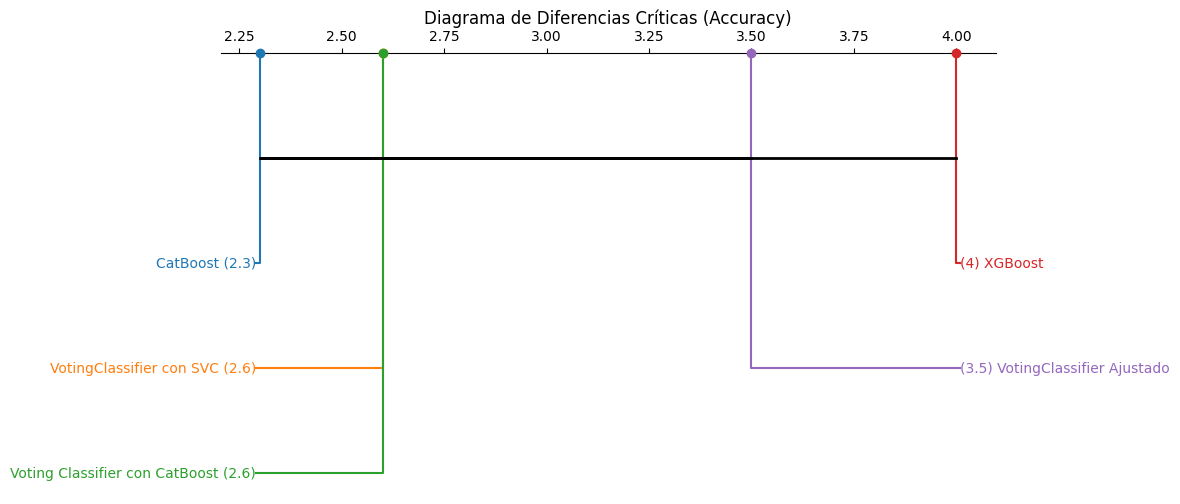

XGBoost                           4.0
CatBoost                          2.6
VotingClassifier con SVC          2.2
VotingClassifier Ajustado         3.6
Voting Classifier con CatBoost    2.6
dtype: float64


c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:498: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  key=lambda x: ranks[list(x)].min()
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:518: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

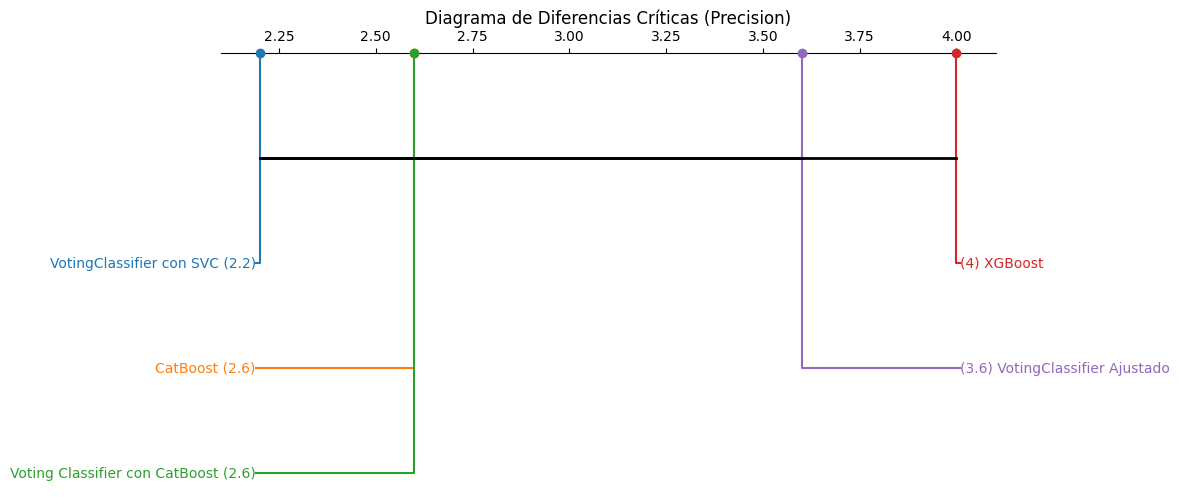

c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:498: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  key=lambda x: ranks[list(x)].min()
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:518: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

XGBoost                           4.0
CatBoost                          2.3
VotingClassifier con SVC          2.6
VotingClassifier Ajustado         3.5
Voting Classifier con CatBoost    2.6
dtype: float64


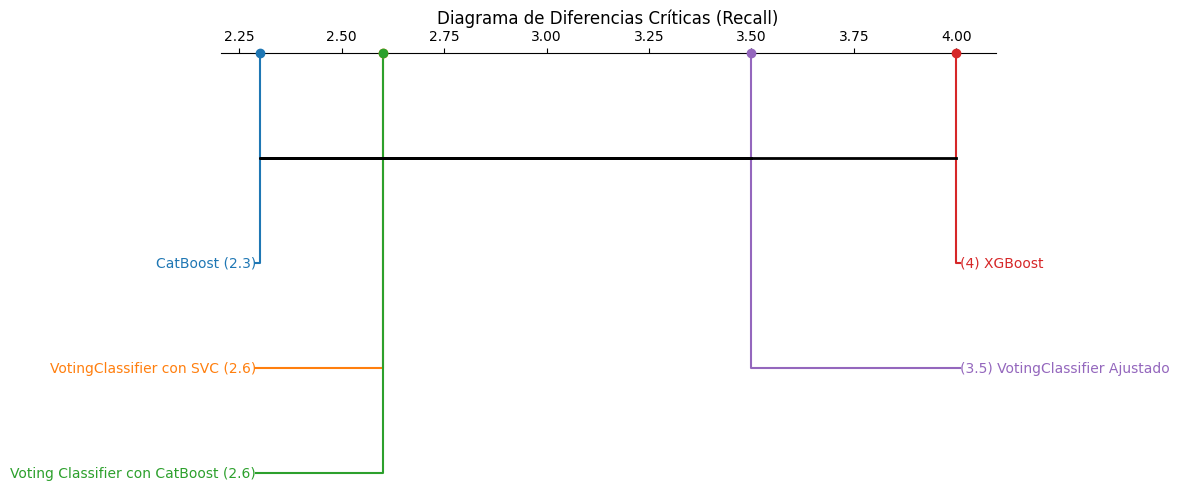

XGBoost                           4.0
CatBoost                          2.2
VotingClassifier con SVC          2.6
VotingClassifier Ajustado         3.6
Voting Classifier con CatBoost    2.6
dtype: float64


c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:498: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  key=lambda x: ranks[list(x)].min()
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:518: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

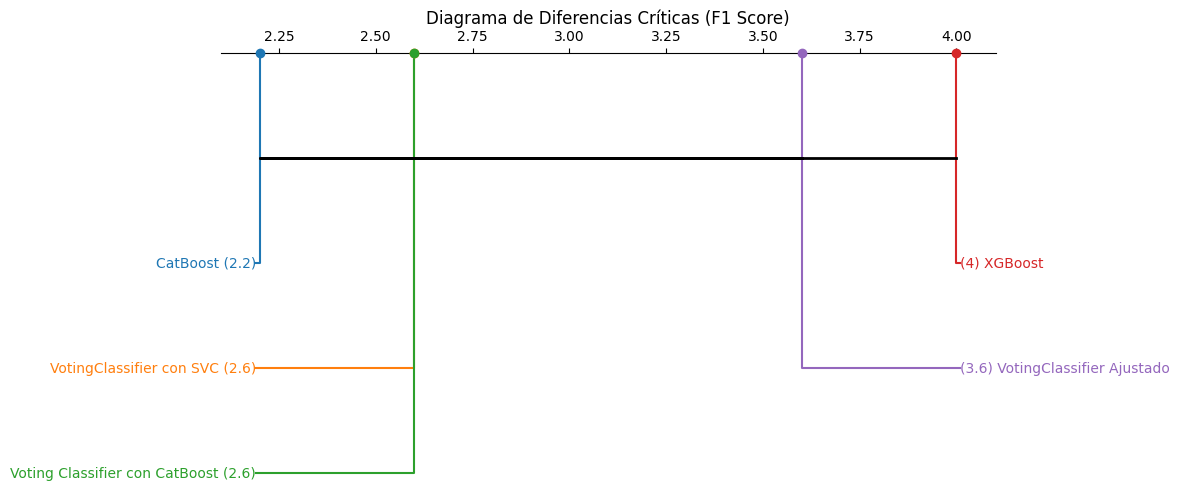

XGBoost                           5.0
CatBoost                          2.2
VotingClassifier con SVC          4.0
VotingClassifier Ajustado         2.4
Voting Classifier con CatBoost    1.4
dtype: float64


c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:498: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  key=lambda x: ranks[list(x)].min()
c:\Users\Manuel Montufar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scikit_posthocs\_plotting.py:518: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

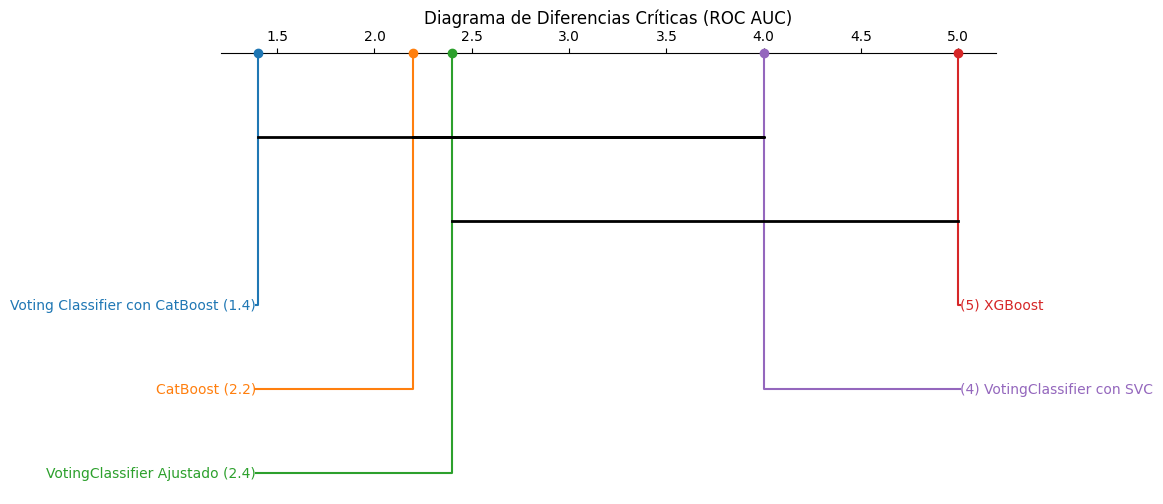

In [11]:
# Function to calculate and visualize critical differences using scikit-posthocs
def calcular_diferencias_criticas(df, metric_name):
    try:
        # Calcular los rangos promedio de los modelos
        avg_rank = df.rank(axis=1).mean(axis=0)
        print(avg_rank)

        # Realizar la prueba post-hoc de Nemenyi
        cd_result = sp.posthoc_nemenyi_friedman(df.values)

        # Graficar el diagrama de diferencias críticas
        plt.figure(figsize=(10, 6), dpi=100)
        plt.title(f'Diagrama de Diferencias Críticas ({metric_name})')
        sp.critical_difference_diagram(avg_rank, cd_result)
        plt.show()

    except ValueError as e:
        print(f"Error al calcular diferencias críticas para {metric_name}: {e}")

# Calcular y graficar diferencias críticas para cada métrica
calcular_diferencias_criticas(accuracy_df, 'Accuracy')
calcular_diferencias_criticas(precision_df, 'Precision')
calcular_diferencias_criticas(recall_df, 'Recall')
calcular_diferencias_criticas(f1_df, 'F1 Score')
calcular_diferencias_criticas(roc_auc_df, 'ROC AUC')


### Curvas ROC AUC

0:	learn: 0.6591123	total: 2.76ms	remaining: 4.14s
1:	learn: 0.6244503	total: 5.46ms	remaining: 4.09s
2:	learn: 0.5988250	total: 8.1ms	remaining: 4.04s
3:	learn: 0.5825239	total: 10.6ms	remaining: 3.98s
4:	learn: 0.5678660	total: 13.2ms	remaining: 3.96s
5:	learn: 0.5557319	total: 15.7ms	remaining: 3.92s
6:	learn: 0.5441081	total: 18.6ms	remaining: 3.96s
7:	learn: 0.5315703	total: 21.2ms	remaining: 3.96s
8:	learn: 0.5222103	total: 24ms	remaining: 3.98s
9:	learn: 0.5127548	total: 26.8ms	remaining: 3.99s
10:	learn: 0.5061315	total: 29.3ms	remaining: 3.96s
11:	learn: 0.4998687	total: 32.2ms	remaining: 4s
12:	learn: 0.4924547	total: 35.4ms	remaining: 4.04s
13:	learn: 0.4872452	total: 38.1ms	remaining: 4.05s
14:	learn: 0.4822803	total: 40.9ms	remaining: 4.05s
15:	learn: 0.4785141	total: 43.9ms	remaining: 4.07s
16:	learn: 0.4745964	total: 46.6ms	remaining: 4.07s
17:	learn: 0.4698663	total: 49.4ms	remaining: 4.07s
18:	learn: 0.4673741	total: 52.1ms	remaining: 4.06s
19:	learn: 0.4643544	total: 

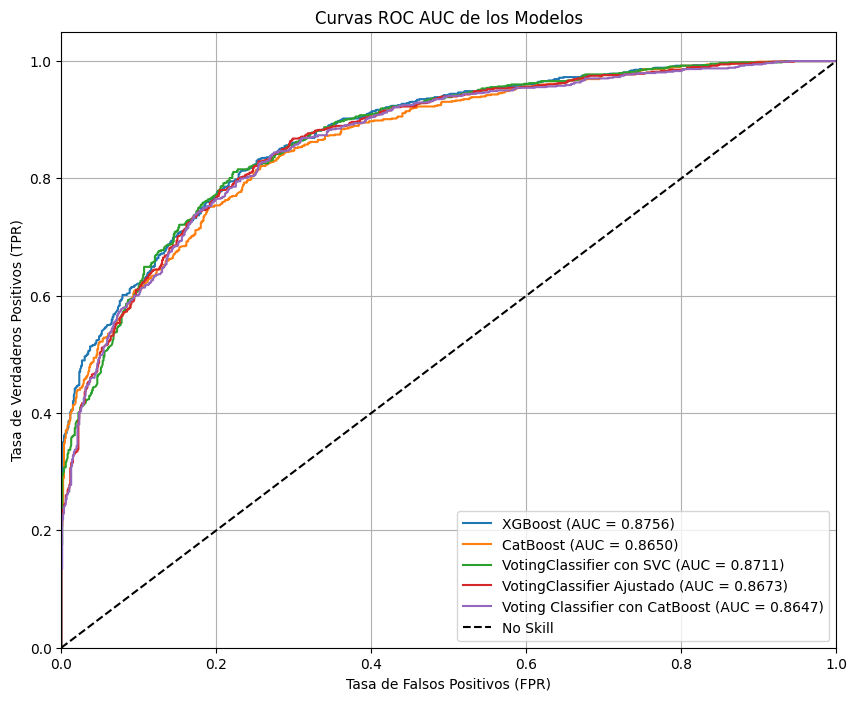

In [12]:
# Diccionario final con todos los clasificadores
classifiers = {
    'XGBoost': xgb,
    'CatBoost': cat_boost,
    'VotingClassifier con SVC': voting_clf_svc,
    'VotingClassifier Ajustado': voting_good,
    'Voting Classifier con CatBoost': voting_cat
}

# Graficar las curvas ROC AUC
plt.figure(figsize=(10, 8))

for model_name, model in classifiers.items():
    # Entrenar el modelo
    model.fit(X_train, y_train)
    
    # Predecir las probabilidades en el conjunto de prueba
    y_prob = model.predict_proba(X_test)[:, 1]  # Obtener la probabilidad de la clase positiva
    
    # Calcular las curvas ROC y AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    # Graficar la curva ROC
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})')

# Ajustar los ejes y etiquetas
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC AUC de los Modelos')
plt.legend(loc='lower right')
plt.grid()
plt.show()

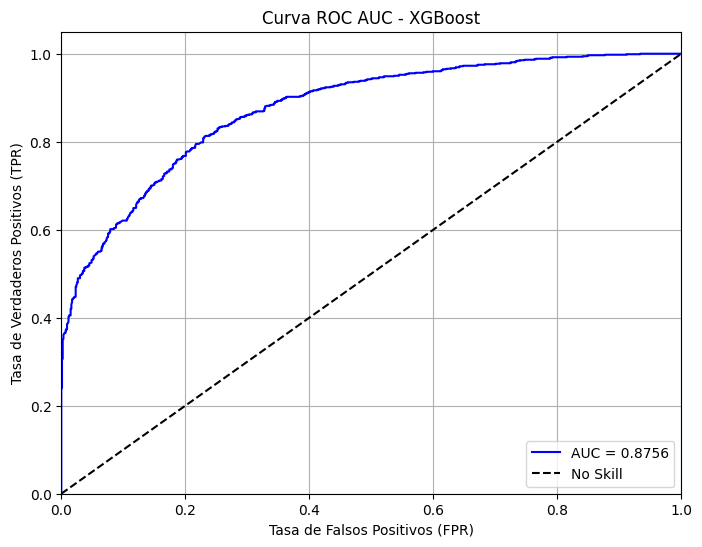

0:	learn: 0.6591123	total: 1.55ms	remaining: 2.32s
1:	learn: 0.6244503	total: 3.15ms	remaining: 2.36s
2:	learn: 0.5988250	total: 4.73ms	remaining: 2.36s
3:	learn: 0.5825239	total: 6.21ms	remaining: 2.32s
4:	learn: 0.5678660	total: 7.89ms	remaining: 2.36s
5:	learn: 0.5557319	total: 9.62ms	remaining: 2.4s
6:	learn: 0.5441081	total: 11.1ms	remaining: 2.37s
7:	learn: 0.5315703	total: 12.5ms	remaining: 2.33s
8:	learn: 0.5222103	total: 14ms	remaining: 2.32s
9:	learn: 0.5127548	total: 15.5ms	remaining: 2.31s
10:	learn: 0.5061315	total: 16.8ms	remaining: 2.28s
11:	learn: 0.4998687	total: 18.3ms	remaining: 2.26s
12:	learn: 0.4924547	total: 19.7ms	remaining: 2.25s
13:	learn: 0.4872452	total: 21.3ms	remaining: 2.26s
14:	learn: 0.4822803	total: 23.1ms	remaining: 2.29s
15:	learn: 0.4785141	total: 24.6ms	remaining: 2.28s
16:	learn: 0.4745964	total: 26.3ms	remaining: 2.29s
17:	learn: 0.4698663	total: 27.8ms	remaining: 2.29s
18:	learn: 0.4673741	total: 29.8ms	remaining: 2.32s
19:	learn: 0.4643544	tota

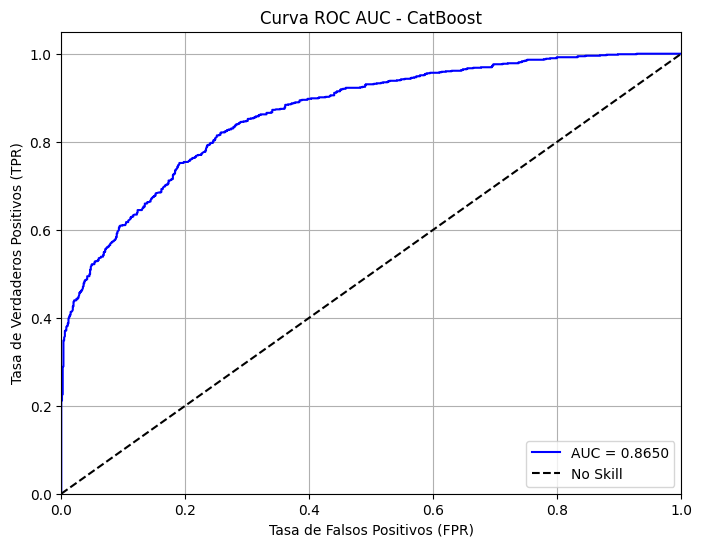

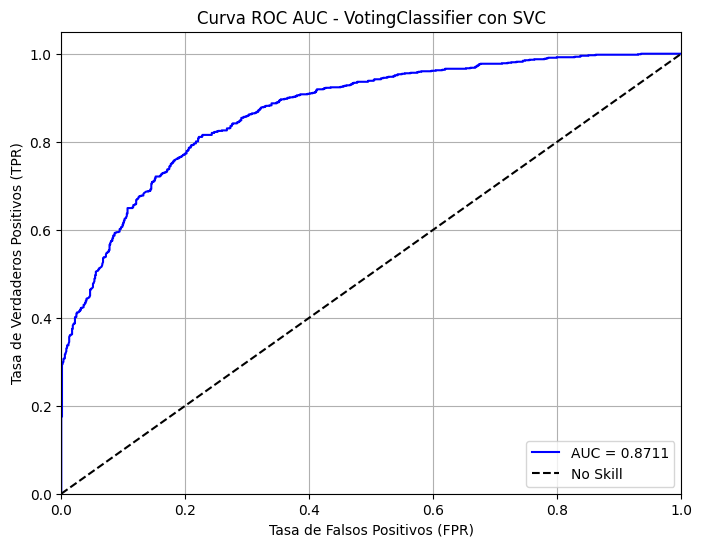

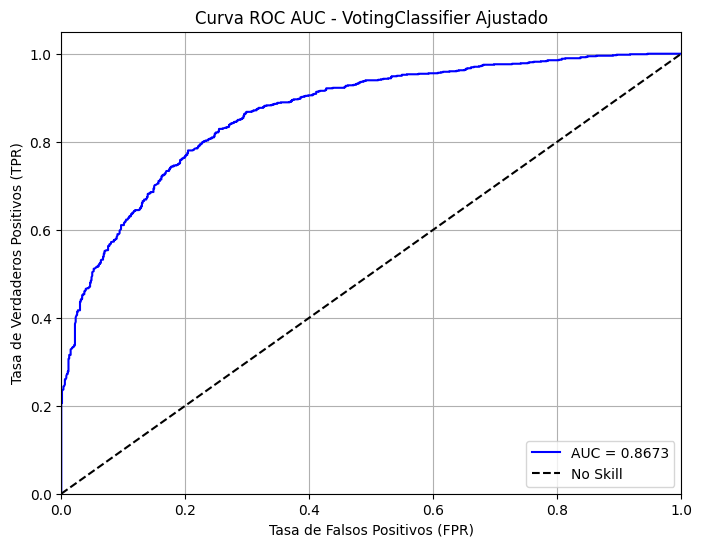

0:	learn: 0.6591123	total: 2.85ms	remaining: 4.27s
1:	learn: 0.6244503	total: 5.77ms	remaining: 4.32s
2:	learn: 0.5988250	total: 9.49ms	remaining: 4.74s
3:	learn: 0.5825239	total: 12.9ms	remaining: 4.82s
4:	learn: 0.5678660	total: 16.1ms	remaining: 4.8s
5:	learn: 0.5557319	total: 18.5ms	remaining: 4.61s
6:	learn: 0.5441081	total: 21.9ms	remaining: 4.67s
7:	learn: 0.5315703	total: 25.2ms	remaining: 4.7s
8:	learn: 0.5222103	total: 27.5ms	remaining: 4.56s
9:	learn: 0.5127548	total: 30.4ms	remaining: 4.54s
10:	learn: 0.5061315	total: 32.8ms	remaining: 4.45s
11:	learn: 0.4998687	total: 35.4ms	remaining: 4.39s
12:	learn: 0.4924547	total: 38.3ms	remaining: 4.38s
13:	learn: 0.4872452	total: 40.9ms	remaining: 4.34s
14:	learn: 0.4822803	total: 43.7ms	remaining: 4.33s
15:	learn: 0.4785141	total: 46.4ms	remaining: 4.3s
16:	learn: 0.4745964	total: 48.8ms	remaining: 4.25s
17:	learn: 0.4698663	total: 51.3ms	remaining: 4.23s
18:	learn: 0.4673741	total: 53.5ms	remaining: 4.17s
19:	learn: 0.4643544	tota

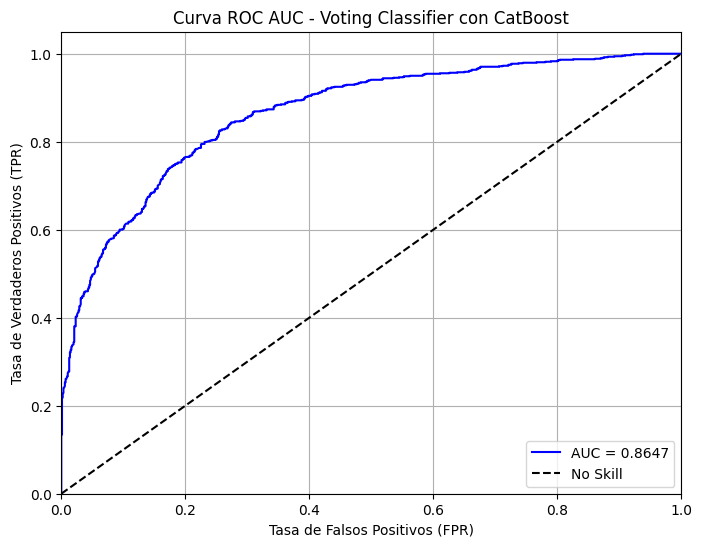

In [13]:
# Diccionario final con todos los clasificadores
classifiers = {
    'XGBoost': xgb,
    'CatBoost': cat_boost,
    'VotingClassifier con SVC': voting_clf_svc,
    'VotingClassifier Ajustado': voting_good,
    'Voting Classifier con CatBoost': voting_cat
}

# Graficar las curvas ROC AUC individualmente
for model_name, model in classifiers.items():
    # Entrenar el modelo
    model.fit(X_train, y_train)
    
    # Predecir las probabilidades en el conjunto de prueba
    y_prob = model.predict_proba(X_test)[:, 1]  # Obtener la probabilidad de la clase positiva
    
    # Calcular las curvas ROC y AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    # Crear una nueva figura para cada modelo
    plt.figure(figsize=(8, 6))
    
    # Graficar la curva ROC
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}', color='blue')
    
    # Graficar la línea diagonal de referencia (No Skill)
    plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
    
    # Ajustar los ejes y etiquetas
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title(f'Curva ROC AUC - {model_name}')
    plt.legend(loc='lower right')
    plt.grid()
    
    # Mostrar el gráfico
    plt.show()


### Matrices de Confusión y Tiempos de Predicción

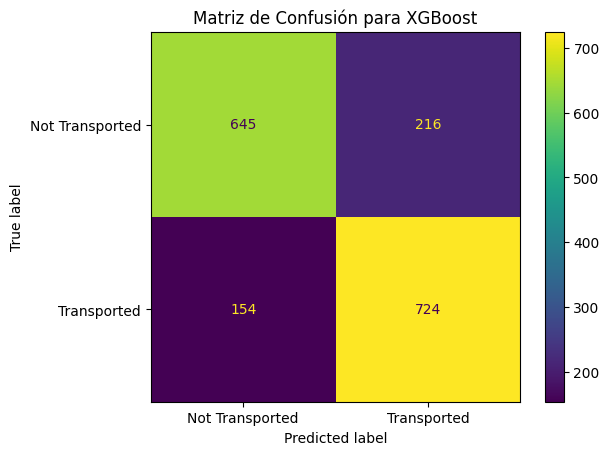

0:	learn: 0.6591123	total: 1.58ms	remaining: 2.38s
1:	learn: 0.6244503	total: 3.49ms	remaining: 2.61s
2:	learn: 0.5988250	total: 5.36ms	remaining: 2.67s
3:	learn: 0.5825239	total: 6.9ms	remaining: 2.58s
4:	learn: 0.5678660	total: 8.27ms	remaining: 2.47s
5:	learn: 0.5557319	total: 9.93ms	remaining: 2.47s
6:	learn: 0.5441081	total: 11.4ms	remaining: 2.44s
7:	learn: 0.5315703	total: 13ms	remaining: 2.42s
8:	learn: 0.5222103	total: 14.5ms	remaining: 2.4s
9:	learn: 0.5127548	total: 16.1ms	remaining: 2.4s
10:	learn: 0.5061315	total: 17.5ms	remaining: 2.36s
11:	learn: 0.4998687	total: 19.2ms	remaining: 2.38s
12:	learn: 0.4924547	total: 20.8ms	remaining: 2.38s
13:	learn: 0.4872452	total: 22.4ms	remaining: 2.38s
14:	learn: 0.4822803	total: 23.8ms	remaining: 2.36s
15:	learn: 0.4785141	total: 25.3ms	remaining: 2.35s
16:	learn: 0.4745964	total: 26.9ms	remaining: 2.35s
17:	learn: 0.4698663	total: 28.4ms	remaining: 2.34s
18:	learn: 0.4673741	total: 29.8ms	remaining: 2.32s
19:	learn: 0.4643544	total:

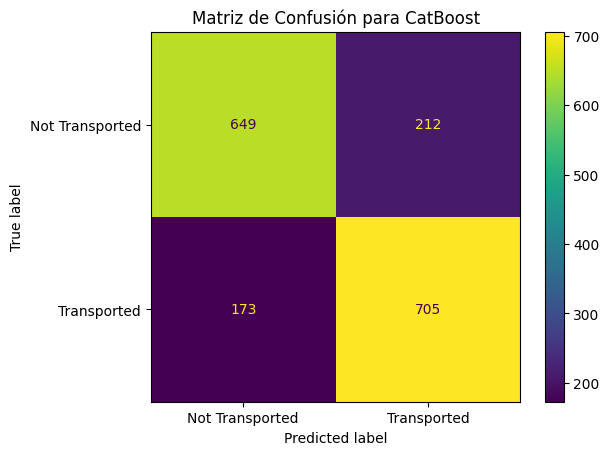

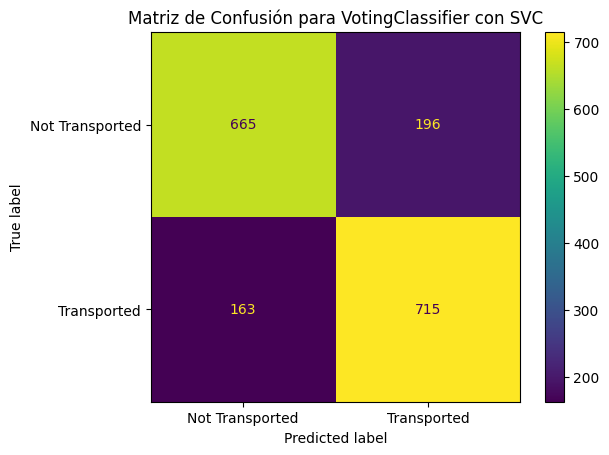

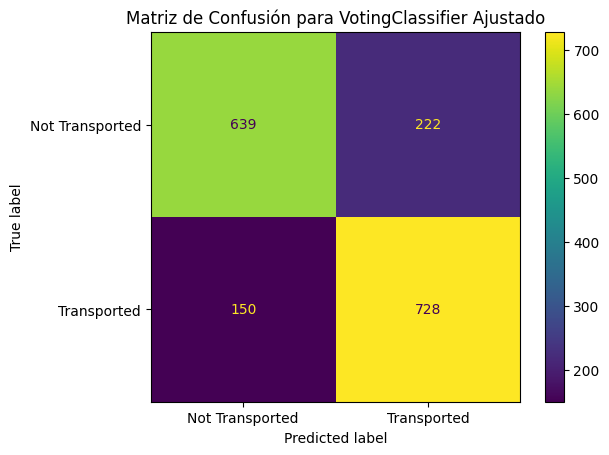

0:	learn: 0.6591123	total: 3.58ms	remaining: 5.37s
1:	learn: 0.6244503	total: 5.37ms	remaining: 4.02s
2:	learn: 0.5988250	total: 8.63ms	remaining: 4.31s
3:	learn: 0.5825239	total: 11.1ms	remaining: 4.14s
4:	learn: 0.5678660	total: 14.4ms	remaining: 4.32s
5:	learn: 0.5557319	total: 17.8ms	remaining: 4.44s
6:	learn: 0.5441081	total: 20.9ms	remaining: 4.46s
7:	learn: 0.5315703	total: 23.1ms	remaining: 4.31s
8:	learn: 0.5222103	total: 26ms	remaining: 4.3s
9:	learn: 0.5127548	total: 27.7ms	remaining: 4.13s
10:	learn: 0.5061315	total: 29.6ms	remaining: 4.01s
11:	learn: 0.4998687	total: 31.5ms	remaining: 3.9s
12:	learn: 0.4924547	total: 33.3ms	remaining: 3.8s
13:	learn: 0.4872452	total: 35.2ms	remaining: 3.73s
14:	learn: 0.4822803	total: 37ms	remaining: 3.67s
15:	learn: 0.4785141	total: 38.9ms	remaining: 3.6s
16:	learn: 0.4745964	total: 40.7ms	remaining: 3.55s
17:	learn: 0.4698663	total: 42.4ms	remaining: 3.49s
18:	learn: 0.4673741	total: 44.2ms	remaining: 3.44s
19:	learn: 0.4643544	total: 46

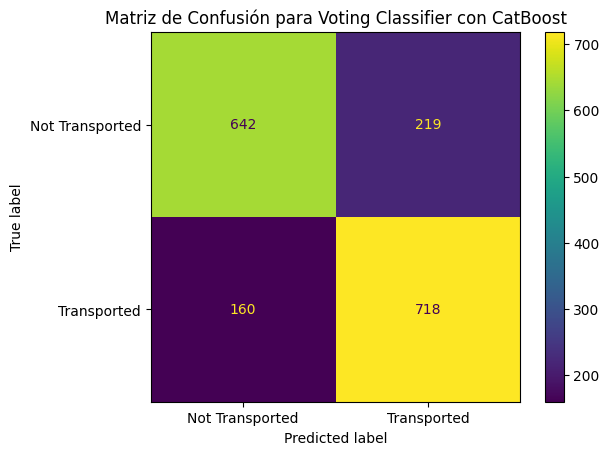

Tiempos de predicción (en segundos):
XGBoost: 0.8253 segundos
CatBoost: 2.5614 segundos
VotingClassifier con SVC: 15.9255 segundos
VotingClassifier Ajustado: 2.5419 segundos
Voting Classifier con CatBoost: 4.6532 segundos


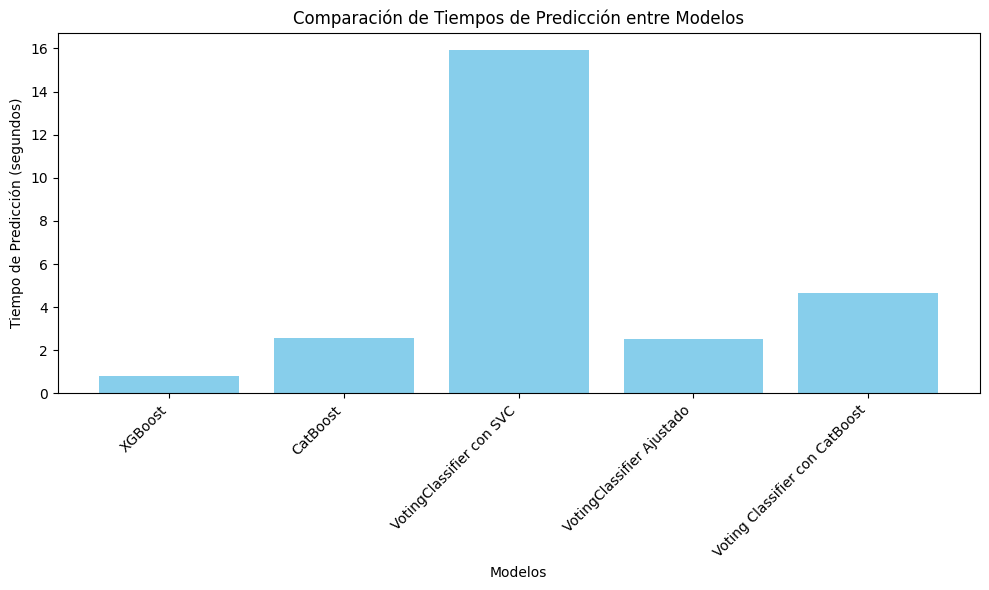

In [14]:
# Diccionario final con todos los clasificadores
classifiers = {
    'XGBoost': xgb,
    'CatBoost': cat_boost,
    'VotingClassifier con SVC': voting_clf_svc,
    'VotingClassifier Ajustado': voting_good,
    'Voting Classifier con CatBoost': voting_cat
}

# DataFrame para almacenar tiempos
prediction_times = {}

# Entrenamiento, predicción y medición de tiempos
for model_name, model in classifiers.items():
    start_time = time.time()
    
    # Entrenar el modelo
    model.fit(X_train, y_train)
    
    # Predecir las etiquetas en el conjunto de prueba
    y_pred = model.predict(X_test)
    
    end_time = time.time()
    
    # Calcular el tiempo de predicción
    elapsed_time = end_time - start_time
    prediction_times[model_name] = elapsed_time

    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    
    # Mostrar la matriz de confusión
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Transported', 'Transported'])
    disp.plot()
    plt.title(f'Matriz de Confusión para {model_name}')
    plt.show()

# Imprimir los tiempos de predicción
print("Tiempos de predicción (en segundos):")
for model_name, elapsed_time in prediction_times.items():
    print(f"{model_name}: {elapsed_time:.4f} segundos")

# Visualizar los tiempos de predicción
plt.figure(figsize=(10, 6))
plt.bar(prediction_times.keys(), prediction_times.values(), color='skyblue')
plt.xlabel('Modelos')
plt.ylabel('Tiempo de Predicción (segundos)')
plt.title('Comparación de Tiempos de Predicción entre Modelos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Comparación Bayesiana

Imágenes guardadas en la carpeta temporal: C:\Users\MANUEL~1\AppData\Local\Temp\tmp9iiekjt0
Comparación bayesiana entre XGBoost y CatBoost en Accuracy: (0.02584496506552827, 0.9734522877455882, 0.0007027471888835235)


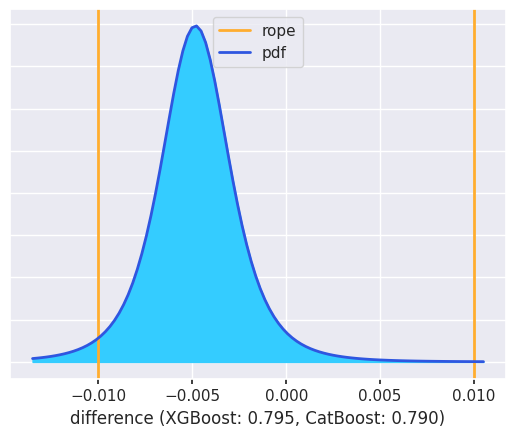

Comparación bayesiana entre XGBoost y VotingClassifier con SVC en Accuracy: (0.09935811575388005, 0.8861024377187972, 0.014539446527322752)


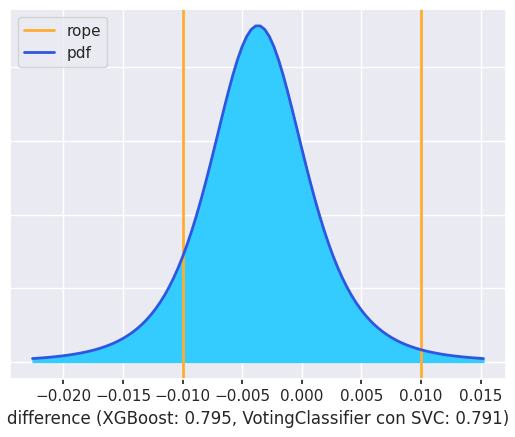

Comparación bayesiana entre XGBoost y VotingClassifier Ajustado en Accuracy: (0.016776648252998894, 0.9738625353527676, 0.009360816394233584)


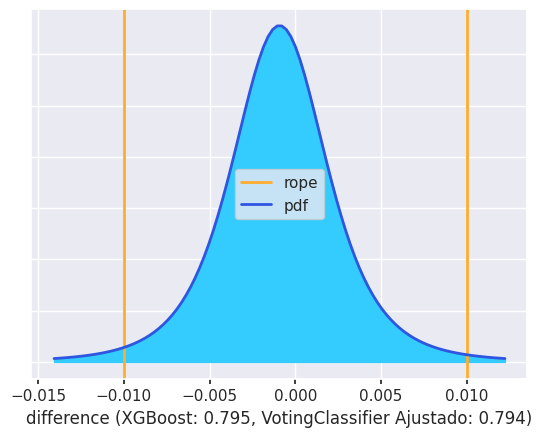

Comparación bayesiana entre XGBoost y Voting Classifier con CatBoost en Accuracy: (0.11674593246101542, 0.8589947372919452, 0.024259330247039412)


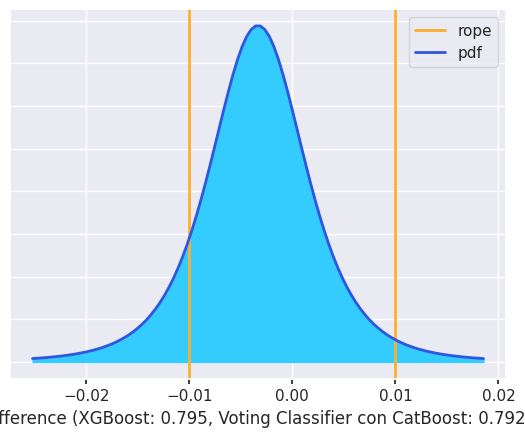

Comparación bayesiana entre CatBoost y VotingClassifier con SVC en Accuracy: (0.05845953417115031, 0.8471620957395265, 0.09437837008932315)


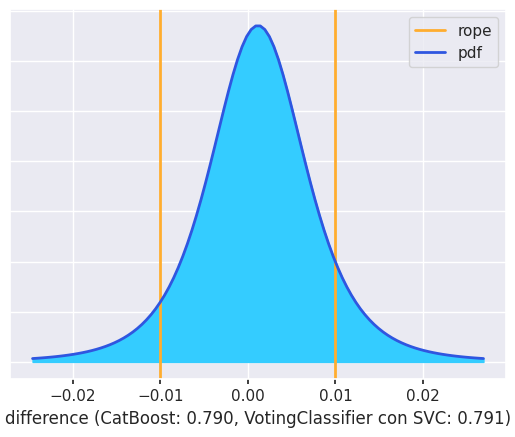

Comparación bayesiana entre CatBoost y VotingClassifier Ajustado en Accuracy: (0.013126051136445455, 0.8836179866212616, 0.10325596224229294)


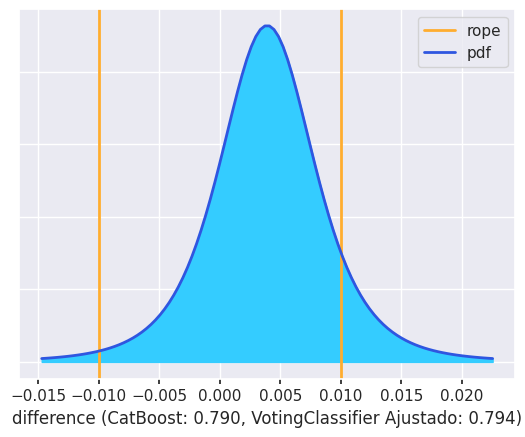

Comparación bayesiana entre CatBoost y Voting Classifier con CatBoost en Accuracy: (0.06642195900136215, 0.8155213419694214, 0.11805669902921645)


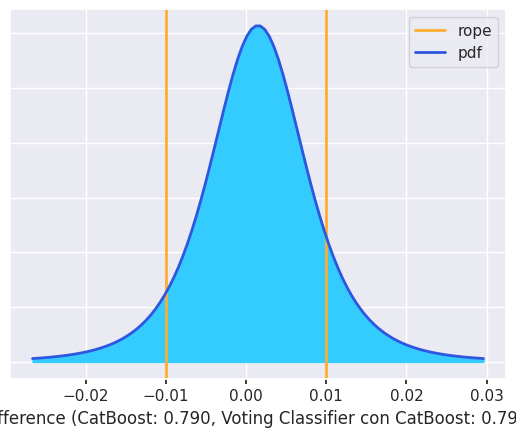

Comparación bayesiana entre VotingClassifier con SVC y VotingClassifier Ajustado en Accuracy: (0.011876290540835523, 0.9310575277492094, 0.057066181709955144)


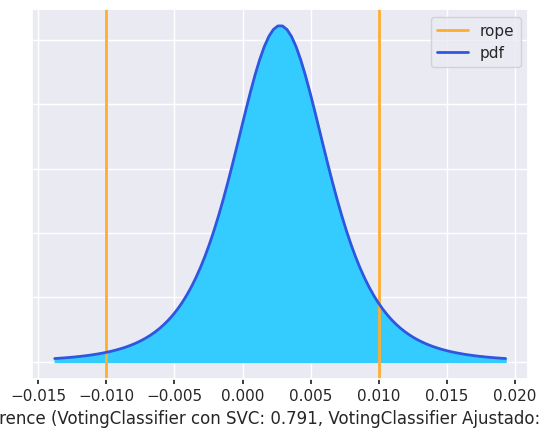

Comparación bayesiana entre VotingClassifier con SVC y Voting Classifier con CatBoost en Accuracy: (0.02748948926381201, 0.9393181856069812, 0.03319232512920678)


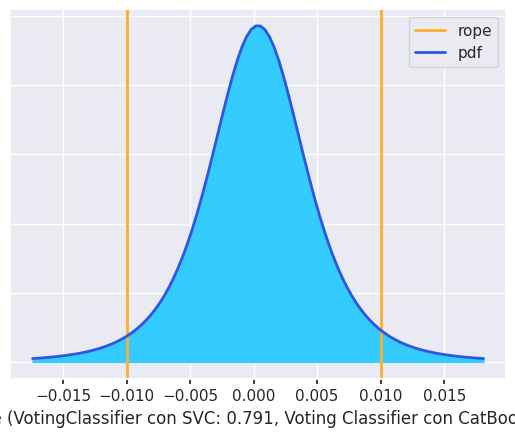

Comparación bayesiana entre VotingClassifier Ajustado y Voting Classifier con CatBoost en Accuracy: (0.029366701220664655, 0.964265331520064, 0.0063679672592713565)


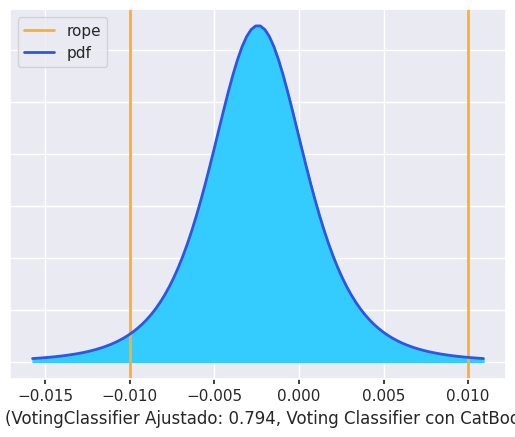

La carpeta C:\Users\MANUEL~1\AppData\Local\Temp\tmp9iiekjt0 ha sido eliminada.
Imágenes guardadas en la carpeta temporal: C:\Users\MANUEL~1\AppData\Local\Temp\tmp_3d4ux06
Comparación bayesiana entre XGBoost y CatBoost en Precision: (0.03679449908830949, 0.9623812119057202, 0.0008242890059703134)


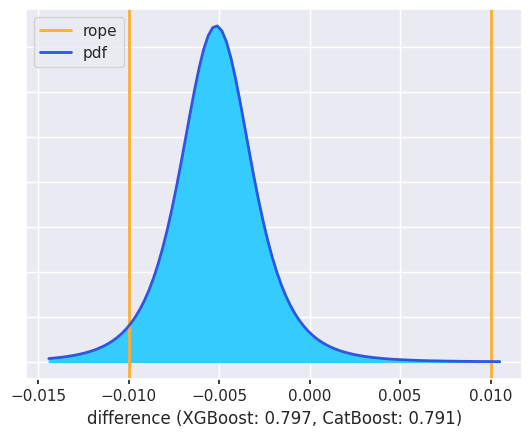

Comparación bayesiana entre XGBoost y VotingClassifier con SVC en Precision: (0.04692704686931332, 0.9491637224608198, 0.0039092306698668144)


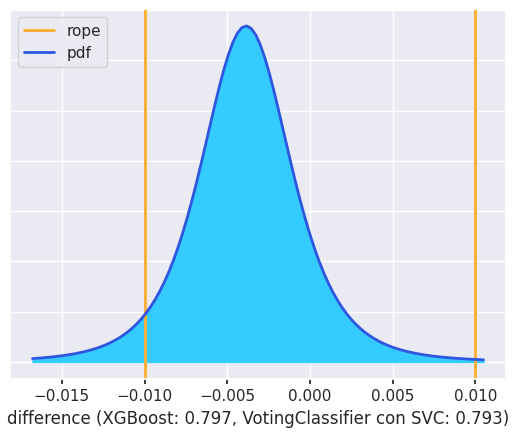

Comparación bayesiana entre XGBoost y VotingClassifier Ajustado en Precision: (0.01300217162236307, 0.9786140842109857, 0.008383744166651219)


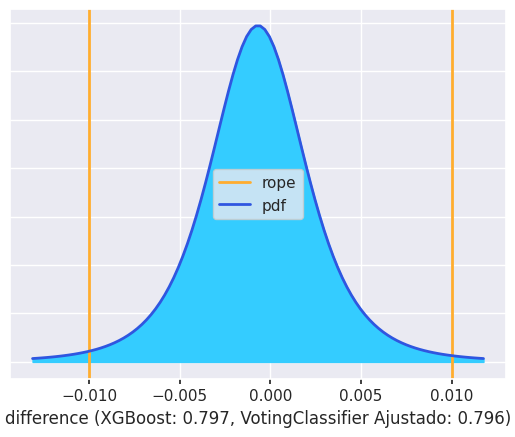

Comparación bayesiana entre XGBoost y Voting Classifier con CatBoost en Precision: (0.11069819724278705, 0.867654385914793, 0.021647416842419887)


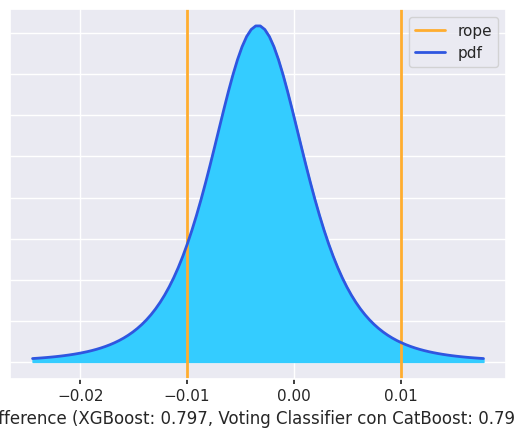

Comparación bayesiana entre CatBoost y VotingClassifier con SVC en Precision: (0.036380691830607575, 0.8956172614061779, 0.06800204676321453)


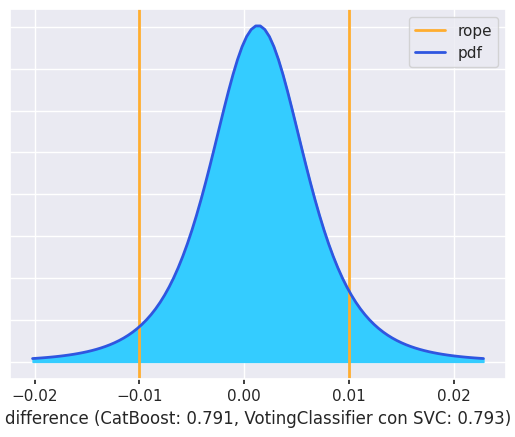

Comparación bayesiana entre CatBoost y VotingClassifier Ajustado en Precision: (0.011945203297891374, 0.8639098505473276, 0.124144946154781)


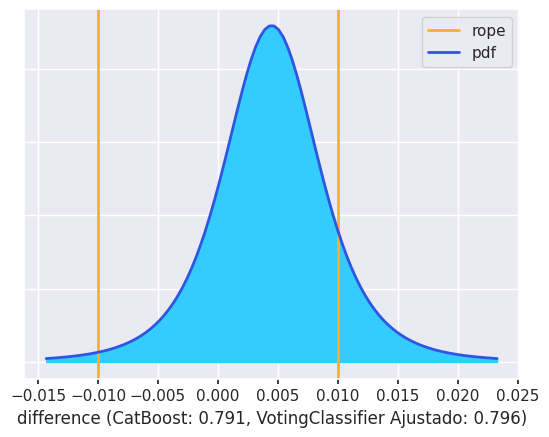

Comparación bayesiana entre CatBoost y Voting Classifier con CatBoost en Precision: (0.06492933946523456, 0.80711322005062, 0.12795744048414537)


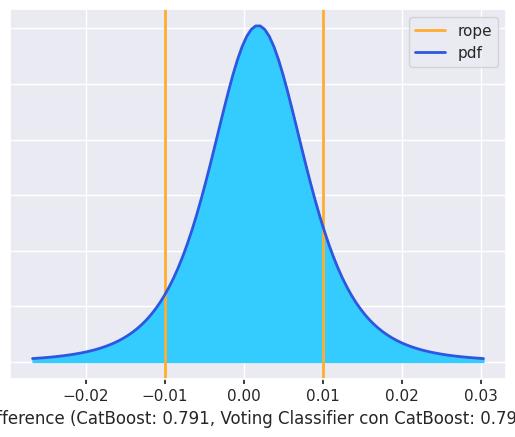

Comparación bayesiana entre VotingClassifier con SVC y VotingClassifier Ajustado en Precision: (0.0036141965382078824, 0.9667358286178769, 0.029649974843915183)


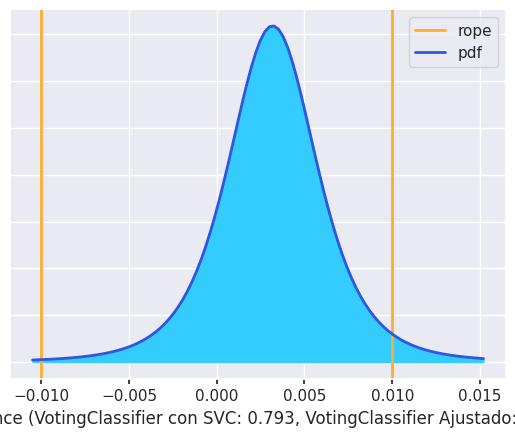

Comparación bayesiana entre VotingClassifier con SVC y Voting Classifier con CatBoost en Precision: (0.021245594528708892, 0.950666327885398, 0.028088077585893156)


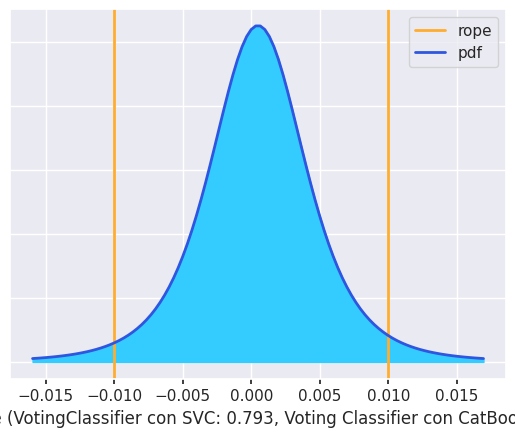

Comparación bayesiana entre VotingClassifier Ajustado y Voting Classifier con CatBoost en Precision: (0.02847613766572118, 0.9665259703977247, 0.004997891936554089)


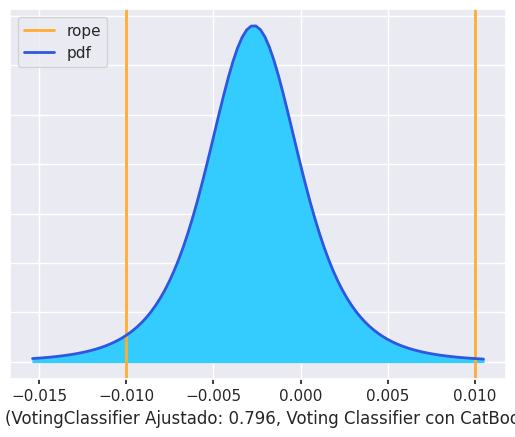

La carpeta C:\Users\MANUEL~1\AppData\Local\Temp\tmp_3d4ux06 ha sido eliminada.
Imágenes guardadas en la carpeta temporal: C:\Users\MANUEL~1\AppData\Local\Temp\tmpkxh4tkhg
Comparación bayesiana entre XGBoost y CatBoost en Recall: (0.02584496506552827, 0.9734522877455882, 0.0007027471888835235)


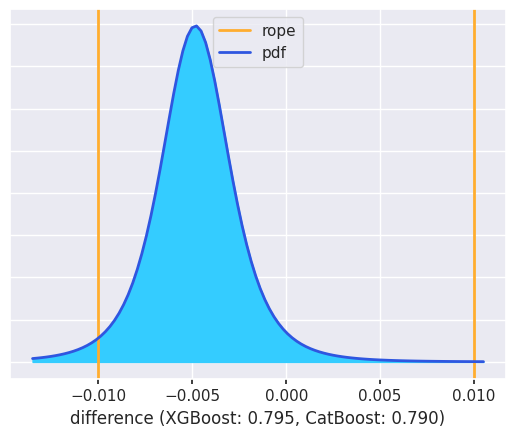

Comparación bayesiana entre XGBoost y VotingClassifier con SVC en Recall: (0.09935811575388005, 0.8861024377187972, 0.014539446527322752)


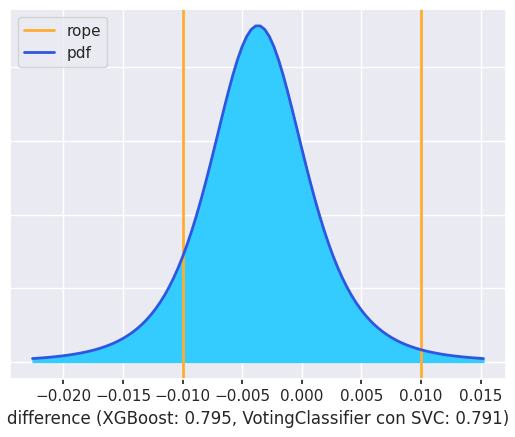

Comparación bayesiana entre XGBoost y VotingClassifier Ajustado en Recall: (0.016776648252998894, 0.9738625353527676, 0.009360816394233584)


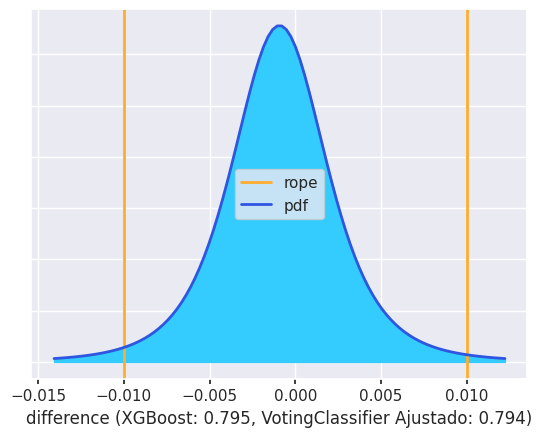

Comparación bayesiana entre XGBoost y Voting Classifier con CatBoost en Recall: (0.11674593246101542, 0.8589947372919452, 0.024259330247039412)


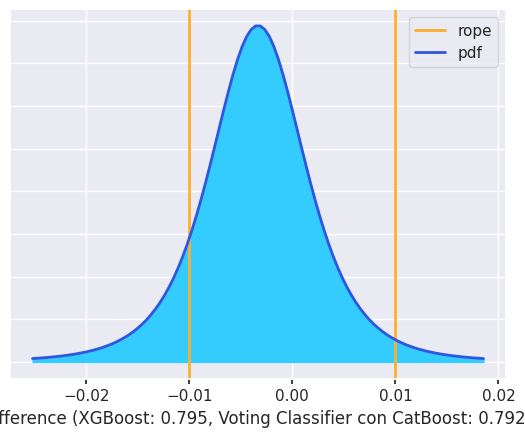

Comparación bayesiana entre CatBoost y VotingClassifier con SVC en Recall: (0.05845953417115031, 0.8471620957395265, 0.09437837008932315)


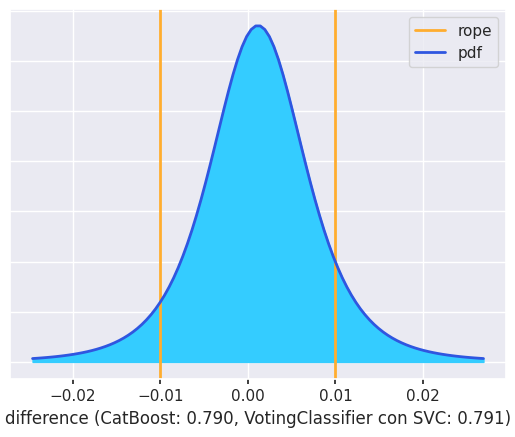

Comparación bayesiana entre CatBoost y VotingClassifier Ajustado en Recall: (0.013126051136445455, 0.8836179866212616, 0.10325596224229294)


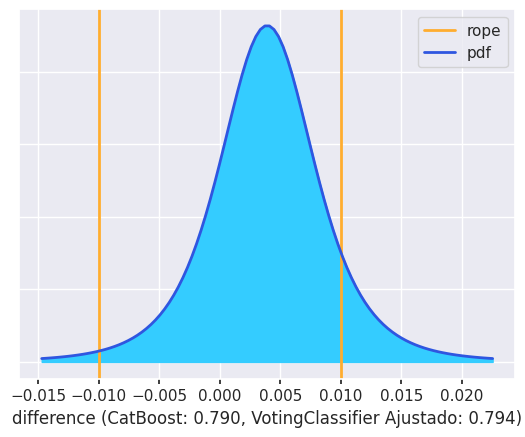

Comparación bayesiana entre CatBoost y Voting Classifier con CatBoost en Recall: (0.06642195900136215, 0.8155213419694214, 0.11805669902921645)


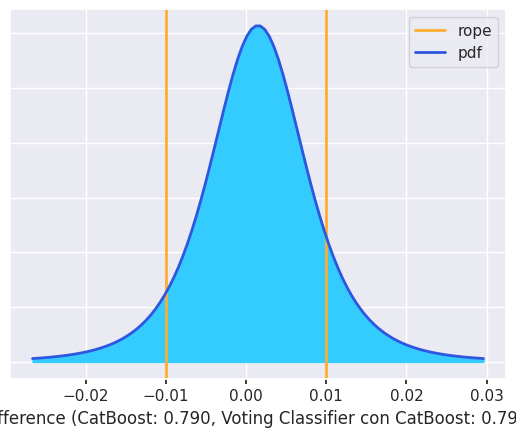

Comparación bayesiana entre VotingClassifier con SVC y VotingClassifier Ajustado en Recall: (0.011876290540835523, 0.9310575277492094, 0.057066181709955144)


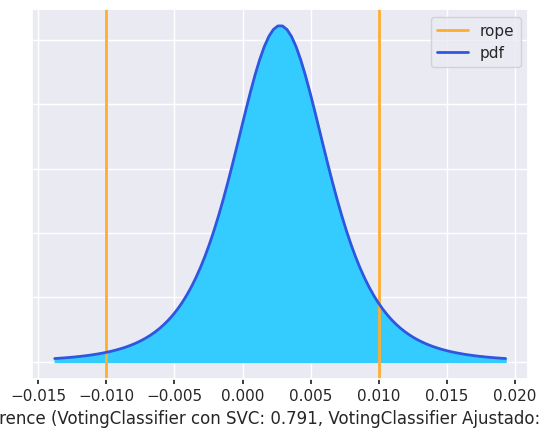

Comparación bayesiana entre VotingClassifier con SVC y Voting Classifier con CatBoost en Recall: (0.02748948926381201, 0.9393181856069812, 0.03319232512920678)


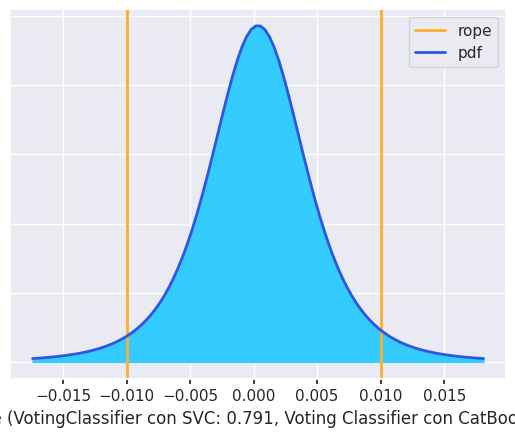

Comparación bayesiana entre VotingClassifier Ajustado y Voting Classifier con CatBoost en Recall: (0.029366701220664655, 0.964265331520064, 0.0063679672592713565)


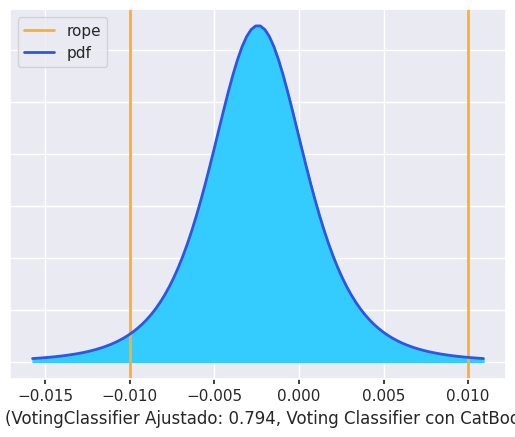

La carpeta C:\Users\MANUEL~1\AppData\Local\Temp\tmpkxh4tkhg ha sido eliminada.
Imágenes guardadas en la carpeta temporal: C:\Users\MANUEL~1\AppData\Local\Temp\tmp7szbo2ly
Comparación bayesiana entre XGBoost y CatBoost en F1 Score: (0.02500830151543192, 0.9742695866424633, 0.0007221118421048001)


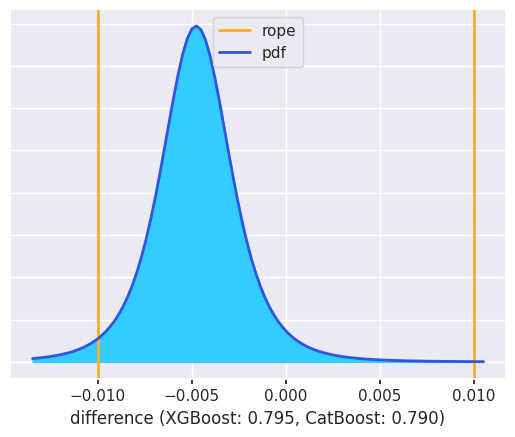

Comparación bayesiana entre XGBoost y VotingClassifier con SVC en F1 Score: (0.10683247675457361, 0.8756501201404692, 0.017517403104957197)


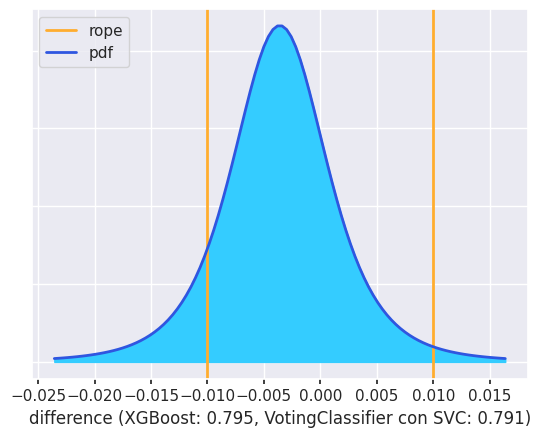

Comparación bayesiana entre XGBoost y VotingClassifier Ajustado en F1 Score: (0.017833282548763398, 0.9724775781751966, 0.009689139276039982)


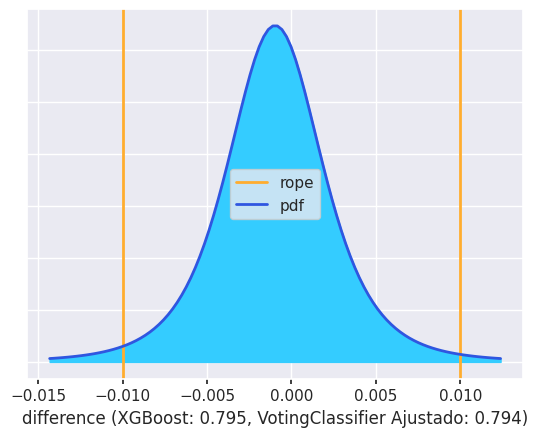

Comparación bayesiana entre XGBoost y Voting Classifier con CatBoost en F1 Score: (0.1181801954281865, 0.8568318793020931, 0.02498792526972038)


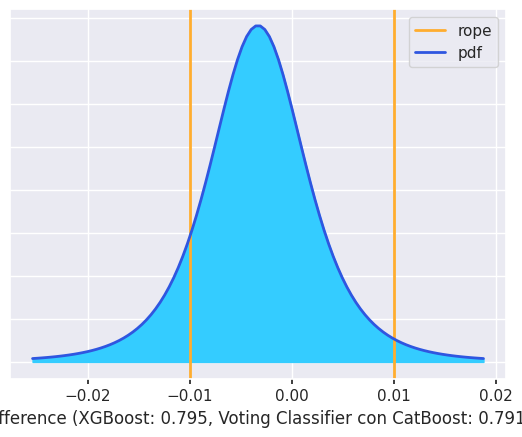

Comparación bayesiana entre CatBoost y VotingClassifier con SVC en F1 Score: (0.062444882491091314, 0.8374076027023167, 0.10014751480659201)


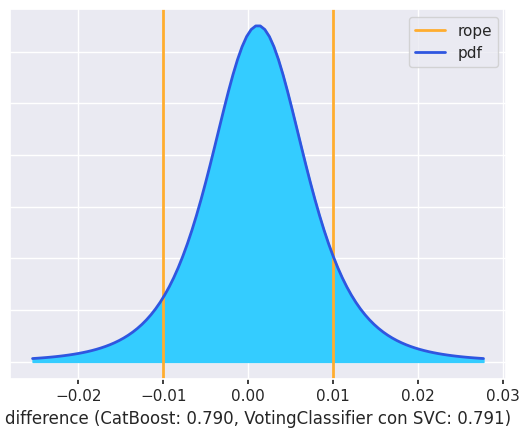

Comparación bayesiana entre CatBoost y VotingClassifier Ajustado en F1 Score: (0.01374879178634566, 0.8854485257150169, 0.10080268249863744)


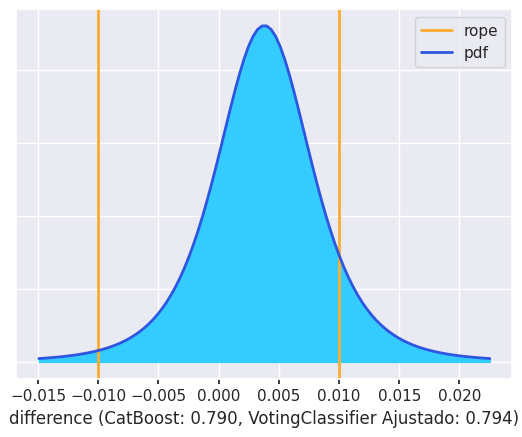

Comparación bayesiana entre CatBoost y Voting Classifier con CatBoost en F1 Score: (0.0674041421631458, 0.8155664928797949, 0.11702936495705929)


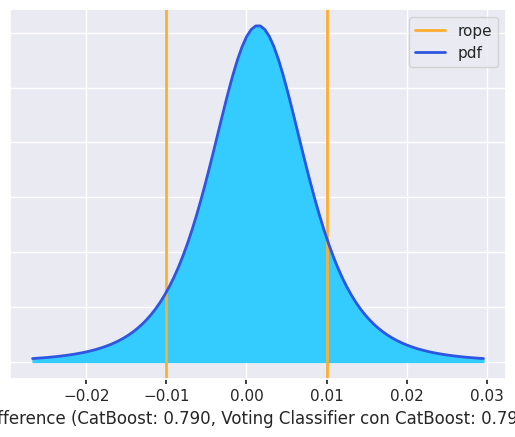

Comparación bayesiana entre VotingClassifier con SVC y VotingClassifier Ajustado en F1 Score: (0.014689766131990883, 0.923049473446575, 0.062260760421434136)


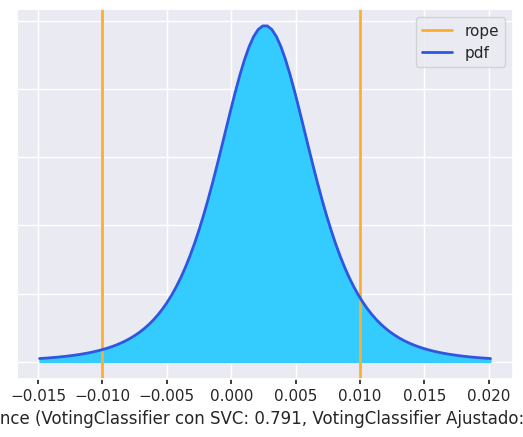

Comparación bayesiana entre VotingClassifier con SVC y Voting Classifier con CatBoost en F1 Score: (0.0301060163491744, 0.9350609388417941, 0.03483304480903149)


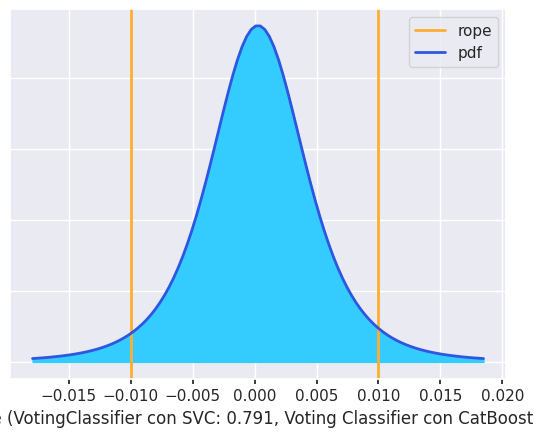

Comparación bayesiana entre VotingClassifier Ajustado y Voting Classifier con CatBoost en F1 Score: (0.02937423246608058, 0.963969685679627, 0.0066560818542923395)


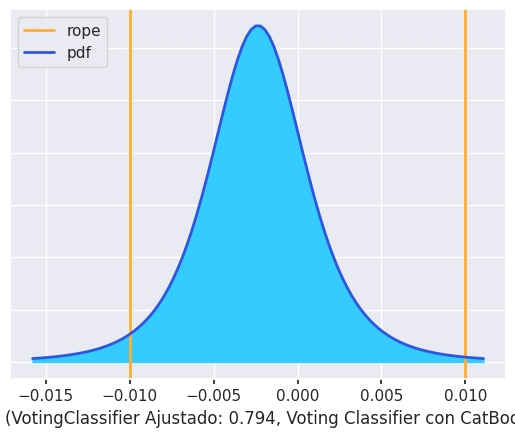

La carpeta C:\Users\MANUEL~1\AppData\Local\Temp\tmp7szbo2ly ha sido eliminada.
Imágenes guardadas en la carpeta temporal: C:\Users\MANUEL~1\AppData\Local\Temp\tmp0ujtcn0b
Comparación bayesiana entre XGBoost y CatBoost en ROC AUC: (0.7469590738414467, 0.25301079215584255, 3.013400271079103e-05)


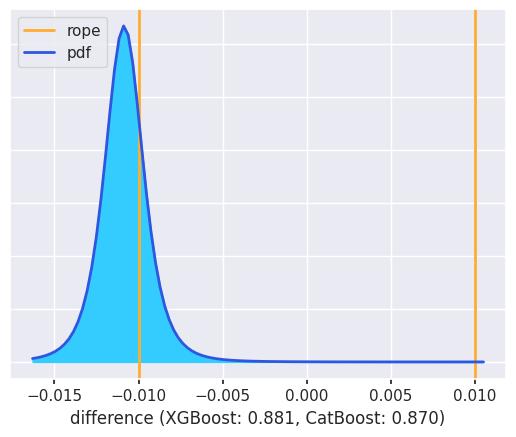

Comparación bayesiana entre XGBoost y VotingClassifier con SVC en ROC AUC: (0.048320373418336005, 0.950667002290128, 0.001012624291536035)


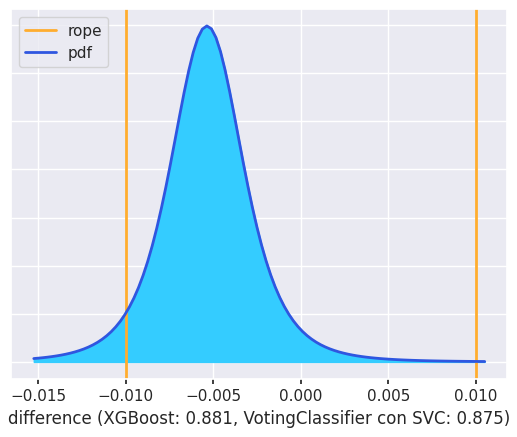

Comparación bayesiana entre XGBoost y VotingClassifier Ajustado en ROC AUC: (0.6159406024926006, 0.38273852081687565, 0.0013208766905237201)


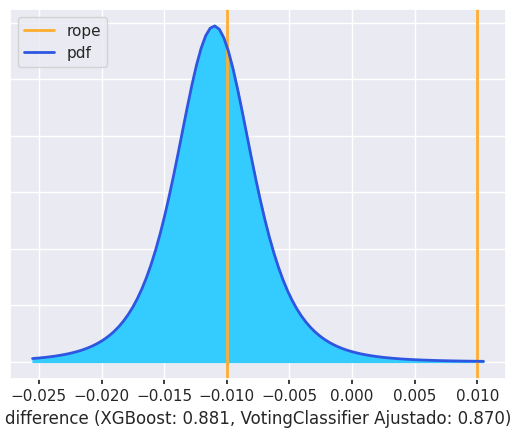

Comparación bayesiana entre XGBoost y Voting Classifier con CatBoost en ROC AUC: (0.785181926285939, 0.21366678534615335, 0.0011512883679076769)


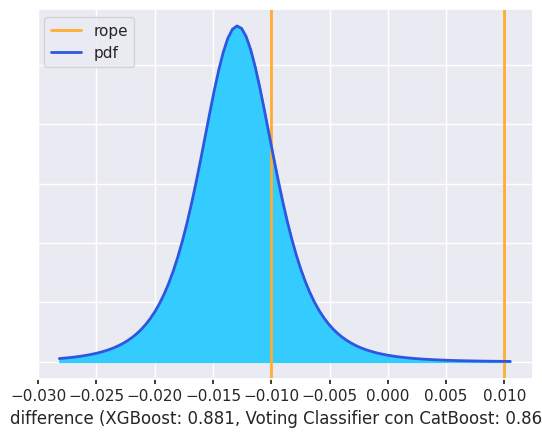

Comparación bayesiana entre CatBoost y VotingClassifier con SVC en ROC AUC: (0.0031963855224208474, 0.8946672411233635, 0.10213637335421566)


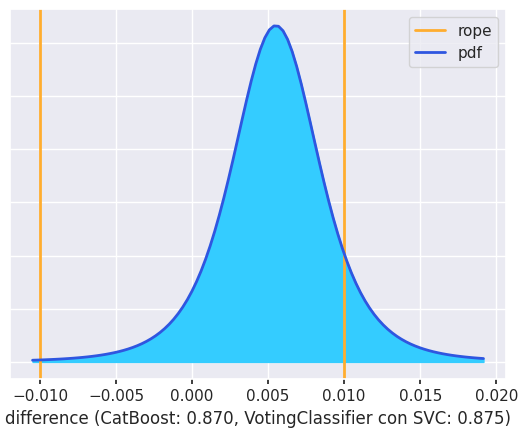

Comparación bayesiana entre CatBoost y VotingClassifier Ajustado en ROC AUC: (0.01601376399572125, 0.9692373228766135, 0.014748913127665242)


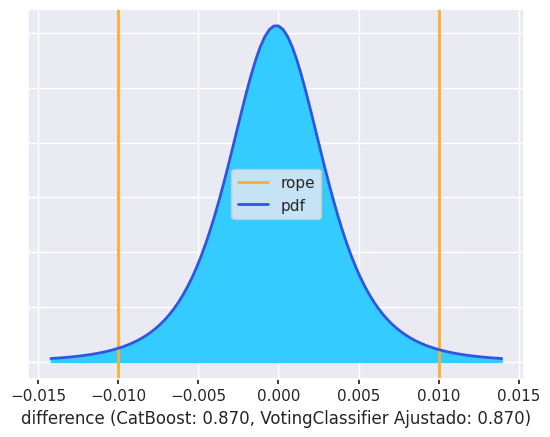

Comparación bayesiana entre CatBoost y Voting Classifier con CatBoost en ROC AUC: (0.029315158559805998, 0.9624493165609688, 0.008235524879225187)


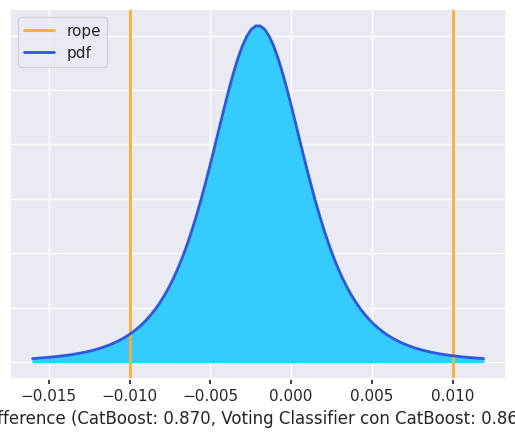

Comparación bayesiana entre VotingClassifier con SVC y VotingClassifier Ajustado en ROC AUC: (0.17028883190959748, 0.8207622791852124, 0.008948888905190189)


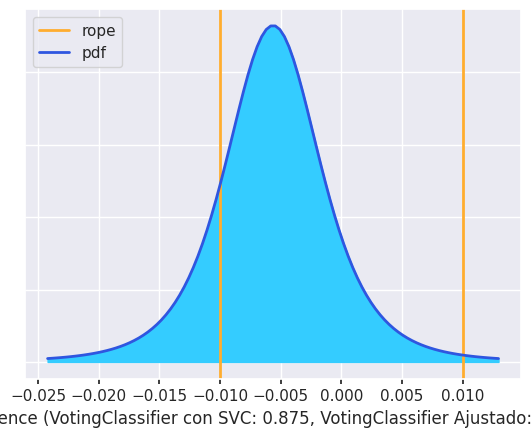

Comparación bayesiana entre VotingClassifier con SVC y Voting Classifier con CatBoost en ROC AUC: (0.2963511555997577, 0.6966238752435641, 0.0070249691566781625)


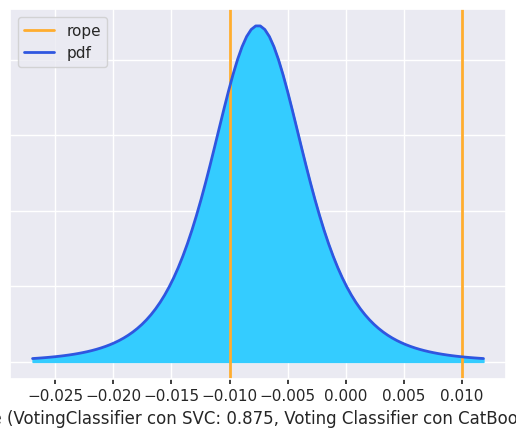

Comparación bayesiana entre VotingClassifier Ajustado y Voting Classifier con CatBoost en ROC AUC: (7.435883177779251e-05, 0.9999096035471069, 1.603762111535012e-05)


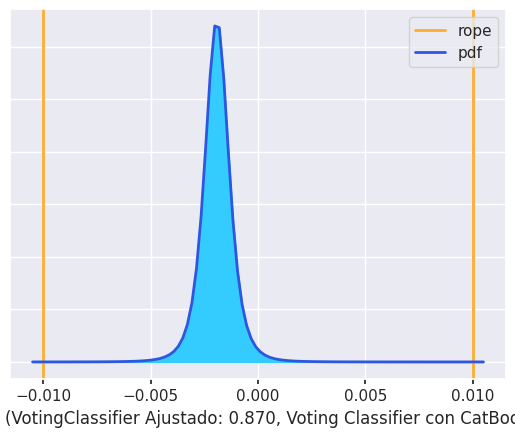

La carpeta C:\Users\MANUEL~1\AppData\Local\Temp\tmp0ujtcn0b ha sido eliminada.


In [15]:
# Función para realizar comparaciones bayesianas entre todos los pares de clasificadores y generar gráficos
def comparaciones_bayesianas(df, nombre_metrica):
    
    rope = 0.01 # Región de Equivalencia Práctica (ROPE)
    bayes_comparison_results = {}

    # Crear una carpeta temporal
    with tempfile.TemporaryDirectory() as temp_dir:
        print(f"Imágenes guardadas en la carpeta temporal: {temp_dir}")
        
        # Comparar todos los pares únicos de modelos
        for i, modelo_1 in enumerate(df.columns):
            for j, modelo_2 in enumerate(df.columns):
                if i < j:  # Evitar comparaciones duplicadas y autocomparaciones
                    # Realizar la comparación bayesiana entre los dos modelos seleccionados usando two_on_single
                    probs, fig = baycomp.two_on_single(
                        df[modelo_1].values,  # Resultados del primer modelo
                        df[modelo_2].values,  # Resultados del segundo modelo
                        rope=rope,
                        plot=True,  # Generar el gráfico
                        names=(modelo_1, modelo_2)  # Nombres para los modelos
                    )
                    bayes_comparison_results[(modelo_1, modelo_2)] = probs
                    # Imprimir los resultados
                    print(f"Comparación bayesiana entre {modelo_1} y {modelo_2} en {nombre_metrica}: {probs}")

                    # Guardar el gráfico en la carpeta temporal
                    image_path = os.path.join(temp_dir, f"Comparacion_Bayesiana_{modelo_1}_vs_{modelo_2}_{nombre_metrica}.png")
                    fig.savefig(image_path)
                    plt.show()
        
        # Mensaje confirmando que la carpeta será eliminada
        print(f"La carpeta {temp_dir} ha sido eliminada.")

    return bayes_comparison_results

# Realizar comparaciones bayesianas para cada métrica y generar los gráficos
resultados_bayesianos_accuracy = comparaciones_bayesianas(accuracy_df, 'Accuracy')
resultados_bayesianos_precision = comparaciones_bayesianas(precision_df, 'Precision')
resultados_bayesianos_recall = comparaciones_bayesianas(recall_df, 'Recall')
resultados_bayesianos_f1 = comparaciones_bayesianas(f1_df, 'F1 Score')
resultados_bayesianos_roc_auc = comparaciones_bayesianas(roc_auc_df, 'ROC AUC')